# KNOW DIABETES-A Data Driven Approach to Early Detection-CAPSTONE PROJECT ##

# **Table of Contents**

## **1. Topic Introduction**
- [Topic Introduction](#topic-introduction)
- [Setup](#setup)

## **2. Data Preparation and Cleaning**
- [Data Loading and Understanding](#data-loading-and-understanding)
- [Formatting & Validity](#formatting-and-validity)
- [Checking for Duplicates and Redundant Information](#checking-duplicates-and-redundant-information)
- [Missing Data](#missing-data)

## **3. Visualization and Analysis**
- [Assessing Which Columns Are Relevant to Our Analysis](#assessing-relevant-columns)
- [Univariate Visualizations — Numerical Features](#univariate-numerical)
- [Summary: Univariate Insights — Numerical](#summary-univariate-numerical)
- [Univariate Visualizations — Categorical Features](#univariate-categorical)
- [Summary: Univariate Insights — Categorical](#summary-univariate-categorical)
- [Multivariate (Numerical) vs Target](#multivariate-numerical-vs-target)
- [Summary: Multivariate Insights — Numerical](#summary-multivariate-numerical)
- [Multivariate (Categorical) vs Target](#multivariate-categorical-vs-target)
- [Summary: Multivariate Insights — Categorical](#summary-multivariate-categorical)

## **4. Feature Engineering**
- [One-Hot Encoding](#feature-engineering-one-hot-encoding)
- [Correlation Matrix and VIF](#correlation-matrix-and-vif)
- [Hypothesis Testing](#hypothesis-testing)
  - [Chi-Squared Test (Independence)](#chi-squared-test)
  - [Two-Sample Unpaired t-Test](#two-sample-unpaired-t-test)
  - [Summary: Feature Significance](#summary-feature-significance)

## **5. Advanced EDA**
- [High Blood Pressure vs High Cholesterol by Diabetes Class](#hbp-vs-cholesterol-by-diabetes)
- [Physical Activity vs Smoker by Diabetes Class](#physical-activity-vs-smoker-by-diabetes)
- [Education Level vs Income by Diabetes Class](#education-vs-income-by-diabetes)
- [Fruits vs Veggies by Diabetes Class](#fruits-vs-veggies-by-diabetes)
- [Age vs Sex by Diabetes Class](#age-vs-sex-by-diabetes)

## **6. Baseline Model**
- [Stratify Split](#stratify-split)
- [Feature Engineering 2 — Standard Scalar](#feature-engineering-2)
- [Logistic Regression — Normal](#logistic-regression-normal)
  - [Classification Report-Normal](#classification-report-normal)
- [Logistic Regression — Balanced](#logistic-regression-balanced)
  - [Classification Report-Balanced](#classification-report-balanced)
- [Logistic Regression Model — Upsampling](#logistic-regression-upsampling)
  - [Classification Report-Upsampling](#classification-report-upsampling)
- [Advanced Evaluation Metrics](#advanced-evaluation-metrics)
- [Decision Tree Model](#decision-tree-model)
- [Summary of Baseline Models (Class 1 — Diabetic)](#summary-baseline-models)

## **7. Model Interpretation**
- [Logistic Regression - Upsampling Interpretation](#logistic-regression-upsample-interpretation)
 


<a id="topic-introduction"></a>
## Topic Introduction


Diabetes is a major public health concern, affecting millions and costing over $320 billion annually in the U.S. alone. This burden impacts both individuals and the healthcare system, underscoring the need for early detection and prevention.

This project uses data from the 2015 Behavioral Risk Factor Surveillance System (BRFSS)—a health-related telephone survey conducted by the Centers for Disease Control and Prevention (CDC)—which includes responses from 253,680 U.S. adults. The goal is to build a machine learning model that predicts at diabetes risk individuals based on key health indicators, enabling early intervention and reducing long-term healthcare costs.

This dataset will be cleaned, wrangled, and prepared for in-depth analysis and modeling to support data-driven preventive strategies.

<a id="setup"></a>
## Setup


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import random
# Helpful extra functionality
from scipy import special
from typing import List, Dict, Optional
import mpl_toolkits.mplot3d as m3d
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import statsmodels.api as sm
from collections import Counter
from scipy import stats
from scipy.stats import norm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.utils import resample
import joblib

<a id="data-loading-and-understanding"></a>
### Data Loading and Understanding


In [2]:
# Setting globally figure size in the notebook
plt.rcParams["figure.figsize"] = (4.0, 3.0)

In [3]:
!pip install ucimlrepo

In [4]:
import sys
!{sys.executable} -m pip install ucimlrepo


In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
  

In [6]:
import pandas as pd

# Correct file path (raw string to avoid backslash issues)
#file_path = r"C:\Users\LENOVO\OneDrive\diabetes_data\diabetes_binary_health_indicators_BRFSS2015.csv"
file_path=r"C:\Users\LENOVO\OneDrive\Desktop\CDC Diabetes 2015 Dataset.csv"

# Load the dataset
diabetes_df = pd.read_csv(file_path)


We will be using health data collected from 253,680 individuals in the United States as part of the Behavioral Risk Factor Surveillance System (BRFSS)—a nationwide health-related telephone survey conducted by the Centers for Disease Control and Prevention (CDC). This dataset was collected in 2015 and will be used to explore health indicators and build a predictive model for diabetes using machine learning.

<a id="data-preparation-and-cleaning"></a>
## Data Preparation and Cleaning


#### Data Dictionary: BRFSS Diabetes Dataset

####  Demographic & Lifestyle Data

| Feature              | Type        | Description                                                                                       | Values / Scale                                                                                      |
|----------------------|-------------|---------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------|
| `Sex`                | Categorical | Biological sex                                                                                    | 0 = Female, 1 = Male                                                                                 |
| `Age`                | Integer     | Age group                                                                                         | 1 = 18–24, 2 =25-29, 3=30-34, 4=35-39, 5 = 40-44.. 9 = 60–64 to 13 = 80+                                                                 |
| `Education`          | Integer     | Education level scale (1–6)                                                                       | 1 = No school, 2 = Grades 1–8, 3 = Some HS, 4 = HS grad, 5 = Some college, 6 = College grad           |
| `Income`             | Integer     | Income bracket scale (1–8)                                                                        | 1 = <$ 10k, ... 5 = < $35k, 8 = ≥ $75k                                                               |
| `PhysActivity`       | Categorical | Physical activity in past 30 days                                                                 | 0 = No, 1 = Yes                                                                                      |
| `Fruits`             | Categorical | Regular fruit consumption                                                                         | 0 = No, 1 = Yes                                                                                      |
| `Smoker`             | Categorical | Smoked ≥ 100 cigarettes in lifetime *(5 packs = 100 cigarettes)*                                 | 0 = No, 1 = Yes                                                                                      |
| `Veggies`            | Categorical | Regular vegetable consumption                                                                     | 0 = No, 1 = Yes                                                                                      |
| `HvyAlcoholConsump`  | Categorical | Heavy alcohol use (Men >14 drinks/week, Women >7)                                                 | 0 = No, 1 = Yes                                                                                      |

---

#### Health & Medical History

| Feature                | Type        | Description                                                                                         | Values / Scale                                                                 |
|------------------------|-------------|-----------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------|
| `HighBP`               | Categorical | High blood pressure                                                                                 | 0 = No, 1 = Yes                                                                 |
| `HighChol`             | Categorical | High cholesterol                                                                                    | 0 = No, 1 = Yes                                                                 |
| `CholCheck`            | Categorical | Cholesterol checked in past 5 years                                                                 | 0 = No, 1 = Yes                                                                 |
| `Stroke`               | Categorical | Ever had a stroke                                                                                   | 0 = No, 1 = Yes                                                                 |
| `HeartDiseaseorAttack`| Categorical | Coronary heart disease or heart attack                                                              | 0 = No, 1 = Yes                                                                 |
| `GenHlth`              | Integer     | General health self-assessment                                                                      | 1 = Excellent to 5 = Poor                                                      |
| `MentHlth`             | Integer     | Days mental health not good (past 30 days)                                                          | Range: 0–30                                                                    |
| `PhysHlth`             | Integer     | Days physical health not good (past 30 days)                                                        | Range: 0–30                                                                    |
| `DiffWalk`             | Categorical | Difficulty walking or climbing stairs                                                               | 0 = No, 1 = Yes                                                                 |
| `HvyAlcoholConsump`    | Categorical | Heavy alcohol use (duplicate for consistency)                                                       | 0 = No, 1 = Yes                                                                 |
| `BMI`                  | Float       | Body Mass Index = weight (kg) / height² (m²)                                                        | Continuous                                                                     |

---

#### Healthcare Access

| Feature           | Type        | Description                                                                                         | Values / Scale |
|-------------------|-------------|-----------------------------------------------------------------------------------------------------|----------------|
| `AnyHealthcare`   | Categorical | Any health coverage (insurance, HMO, etc.)                                                          | 0 = No, 1 = Yes |
| `NoDocbcCost`     | Categorical | Couldn't see doctor in past year due to cost                                                        | 0 = No, 1 = Yes |

---

#### Field of Interest (Target Variable)

| Feature            | Type        | Description                                                    | Values                                  |
|--------------------|-------------|----------------------------------------------------------------|------------------------------------------|
| `Diabetes_binary`  | Categorical | Has diabetes or prediabetes                                    | 0 = No diabetes, 1 = Prediabetes/Diabetes |


<a id="formatting-and-validity"></a>
### Formatting & Validity

Data cleaning can be broken down into three main areas:

   - Checking that datatypes and formatting is all correct.
   - Checking for duplicates.
   - Checking for null (missing) values.
   

In [7]:
diabetes_df #checking our dataframe

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,2,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1


In [8]:
# Rename columns for better readability
diabetes_df.rename(columns={'Diabetes_012':'Diabetes_Class',                
    'HvyAlcoholConsump': 'Heavy_Alcohol_Use',
    'HeartDiseaseorAttack': 'HeartDisease_or_Attack',
    'NoDocbcCost': 'Doctor_unavailable_cost','DiffWalk': 'Difficulty_Walking',
    'Education': 'Education_Level','Age': 'Age_Group',
    'PhysHlth': 'Physical_Health','MentHlth': 'Mental_Health',
    'PhysActivity': 'Physical_Activity','GenHlth': 'General_Health'                       
}, inplace=True)


In [9]:
diabetes_df.head(10) # Quick Look at our first 10 observations

,Diabetes_Class,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,...,AnyHealthcare,Doctor_unavailable_cost,General_Health,Mental_Health,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
5,0,1,1,1,25,1,0,0,1,1,...,1,0,2,0,2,0,1,10,6,8
6,0,1,0,1,30,1,0,0,0,0,...,1,0,3,0,14,0,0,9,6,7
7,0,1,1,1,25,1,0,0,1,0,...,1,0,3,0,0,1,0,11,4,4
8,2,1,1,1,30,1,0,1,0,1,...,1,0,5,30,30,1,0,9,5,1
9,0,0,0,1,24,0,0,0,0,0,...,1,0,2,0,0,0,1,8,4,3


In [10]:
diabetes_df.shape

(253680, 22)

In [11]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_Class,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDisease_or_Attack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
Physical_Activity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [12]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Class           253680 non-null  int64
 1   HighBP                   253680 non-null  int64
 2   HighChol                 253680 non-null  int64
 3   CholCheck                253680 non-null  int64
 4   BMI                      253680 non-null  int64
 5   Smoker                   253680 non-null  int64
 6   Stroke                   253680 non-null  int64
 7   HeartDisease_or_Attack   253680 non-null  int64
 8   Physical_Activity        253680 non-null  int64
 9   Fruits                   253680 non-null  int64
 10  Veggies                  253680 non-null  int64
 11  Heavy_Alcohol_Use        253680 non-null  int64
 12  AnyHealthcare            253680 non-null  int64
 13  Doctor_unavailable_cost  253680 non-null  int64
 14  General_Health           253680 non-

Our data has 253,680 instances with 22 features. However, we know that apart from certain features like BMI, Mental Health and Physical Health (discrete/continous variables), rest all can be converted to int type as they are essentially categorical columns classified in less than 6 different categories and is more suitable for data preprocessing and modelling. In other words, these columns have stored numerically but they are essentially categorical, so it is better to deal with integers rather than float

<a id="checking-duplicates-and-redundant-information"></a>
### Checking for Duplicates and Redundant Information


In [13]:
# Check duplicated rows ONCE and store result
duplicates_mask = diabetes_df.duplicated()
n_duplicates = duplicates_mask.sum()

print(f"Total duplicated rows: {n_duplicates}")
print(f"Percentage duplicated: {duplicates_mask.mean() * 100:.2f}%")

# Check distribution of duplicated rows by target class
dup_class_dist = diabetes_df[duplicates_mask].groupby('Diabetes_Class').size()
print("\nDuplicate Distribution by Target Class:")
print(dup_class_dist)


Total duplicated rows: 23899
Percentage duplicated: 9.42%

Duplicate Distribution by Target Class:
Diabetes_Class
0    23648
1        2
2      249
dtype: int64


***Observations:***

23,899 rows are having duplicated entries. In other words, 9.42 % of our entire data is duplicated. 
When we groupby the target variable, we can see that most of the observations are for NO diabetes class (0), this can further imbalance our dataset.

**However, this approach cannot rule out that the fact that there could be patients with identitical patient profiles. This dataset lacks unique patient identifier and thus to ensure correct representation of all patients, I will not drop the duplicates (9.42% is quite a high number to drop without concrete proof)**

In [14]:
diabetes_df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Class           253680 non-null  int64
 1   HighBP                   253680 non-null  int64
 2   HighChol                 253680 non-null  int64
 3   CholCheck                253680 non-null  int64
 4   BMI                      253680 non-null  int64
 5   Smoker                   253680 non-null  int64
 6   Stroke                   253680 non-null  int64
 7   HeartDisease_or_Attack   253680 non-null  int64
 8   Physical_Activity        253680 non-null  int64
 9   Fruits                   253680 non-null  int64
 10  Veggies                  253680 non-null  int64
 11  Heavy_Alcohol_Use        253680 non-null  int64
 12  AnyHealthcare            253680 non-null  int64
 13  Doctor_unavailable_cost  253680 non-null  int64
 14  General_Health           253680 non-

In [15]:
# Checking for Duplicated Columns
# diabetes_df.T.duplicated()

Here, we can see that there is no duplicated columns or no column is giving repeated information. So we keep all the columns

<a id="missing-data"></a>
### Missing Data


In [16]:
diabetes_df.isna().mean() * 100

Diabetes_Class             0.0
HighBP                     0.0
HighChol                   0.0
CholCheck                  0.0
BMI                        0.0
Smoker                     0.0
Stroke                     0.0
HeartDisease_or_Attack     0.0
Physical_Activity          0.0
Fruits                     0.0
Veggies                    0.0
Heavy_Alcohol_Use          0.0
AnyHealthcare              0.0
Doctor_unavailable_cost    0.0
General_Health             0.0
Mental_Health              0.0
Physical_Health            0.0
Difficulty_Walking         0.0
Sex                        0.0
Age_Group                  0.0
Education_Level            0.0
Income                     0.0
dtype: float64

Here, we can see that there is no NULL values in our dataset. We are good to proceed to Exploratory Data Analysis (EDA)

<a id="visualization-and-analysis"></a>
## Visualization and Analysis


<a id="assessing-relevant-columns"></a>
### Assessing Which Columns Are Relevant to Our Analysis



Before we spend time analyzing the dataset we should determine which columns are actually relevant to what we want answered. This can also be done prior to data cleaning so you don't spend time cleaning columns that you don't need. However, for my dataset, at this point, it is difficult to determine which features are irrelevant and I will keep all of them at this stage.

<a id="univariate-numerical"></a>
### Univariate Visualizations — Numerical Features


In our dataset, apart from Mental Helath, Physical Health and BMI, all the other features are categorical in nature which have certain classification as an outcome. Therefore, let us first explore relationship of numerical columns in our dataset.

In [17]:
# Define the numeric/continuous columns
ncol = ['Mental_Health', 'Physical_Health', 'BMI']

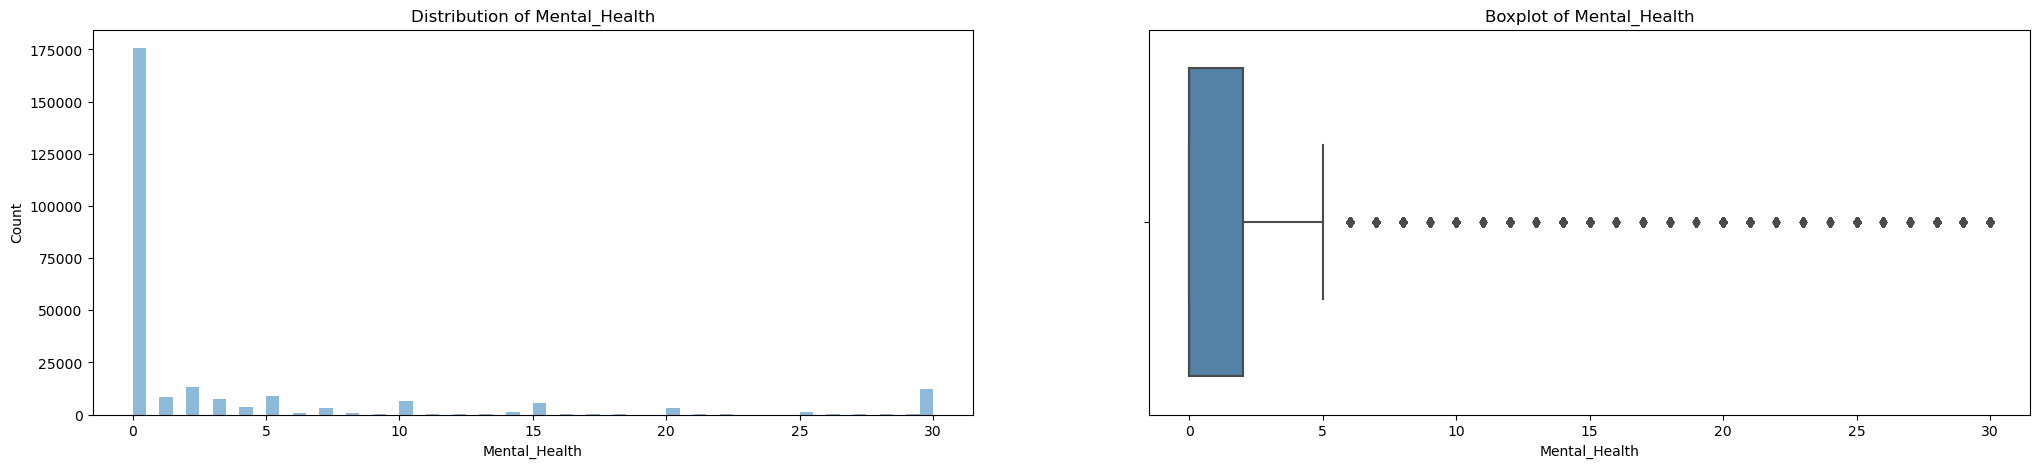

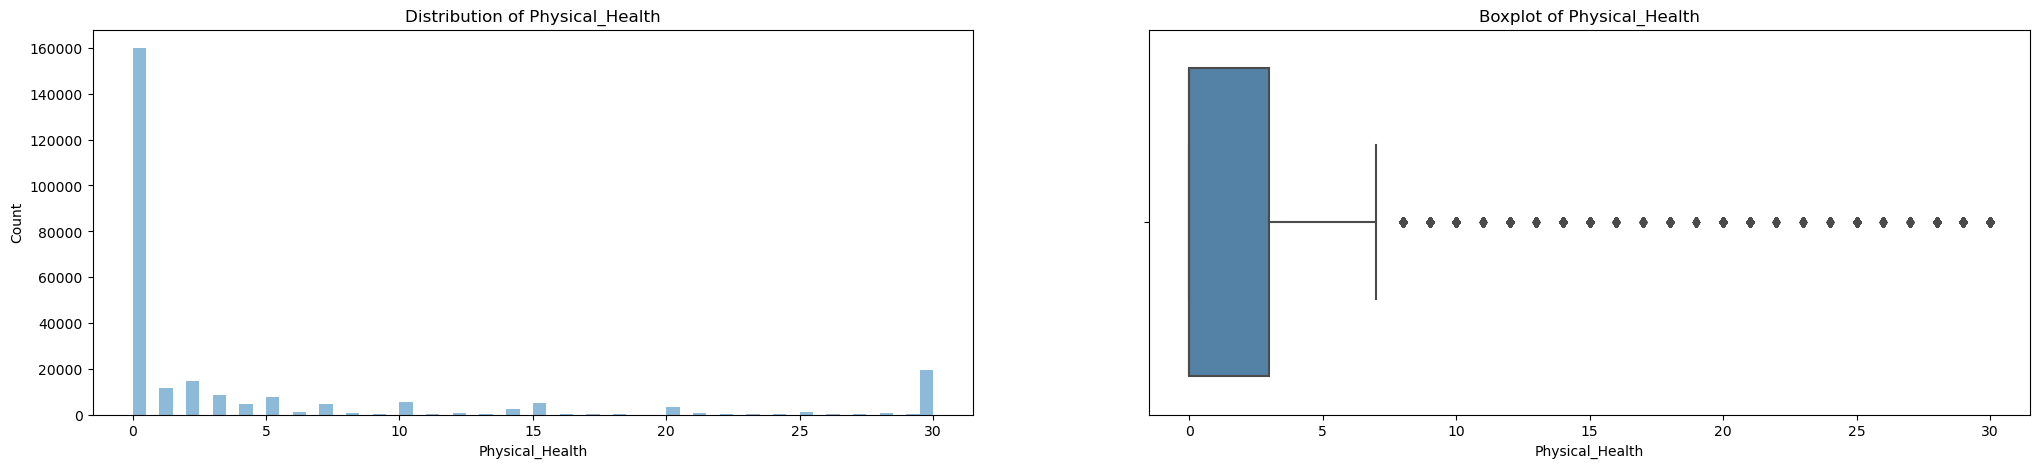

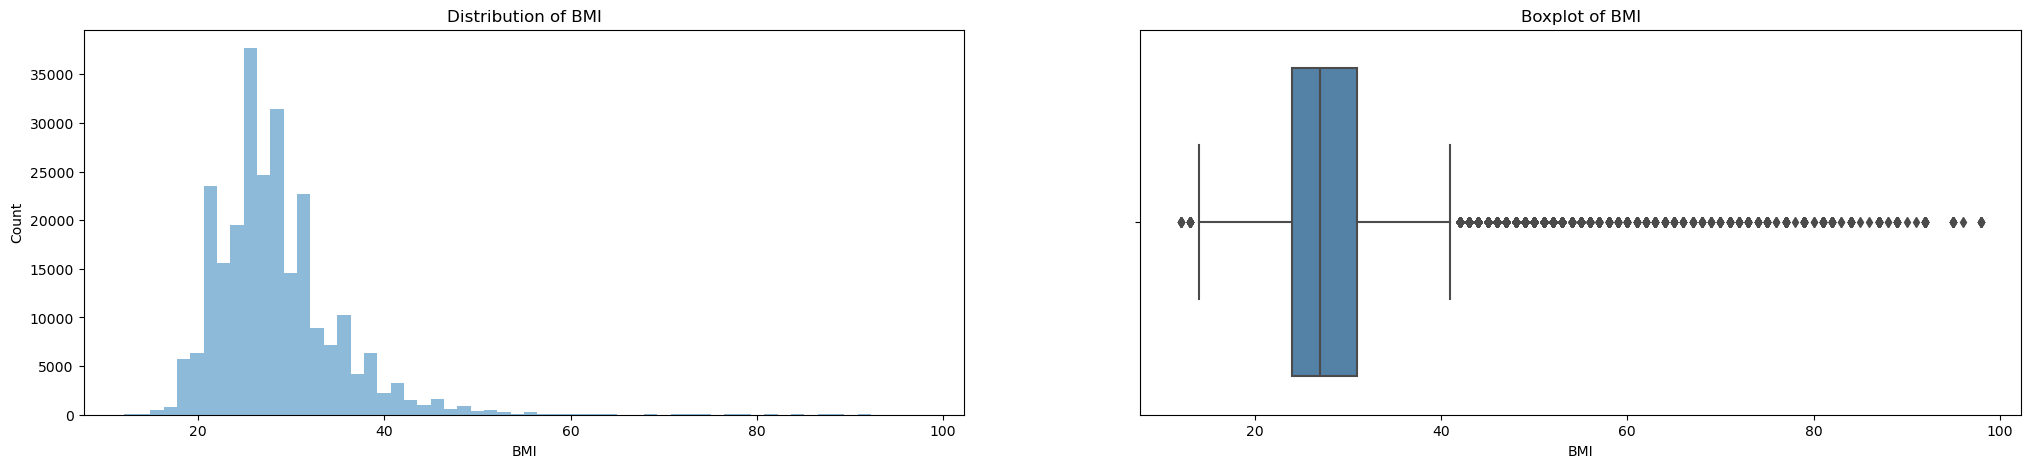

In [18]:
# Use a for loop to generate the plots and use subplots this time
# Visualize the 3 numeric columns using a histogram and boxplot
for column in ncol:
    fig = plt.subplots(1, 2, figsize=(25, 5))

    # Plot out the histogram
    plt.subplot(1, 2, 1)
    plt.hist(diabetes_df[column], bins=60, alpha=0.5)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    # Plot the boxplot. We can use the seaborn boxplot code for this.
    plt.subplot(1, 2, 2)
    sns.boxplot(x=diabetes_df[column], color="steelblue")
    plt.title(f"Boxplot of {column}")

    plt.show()
    

In [19]:
diabetes_df[['Mental_Health', 'Physical_Health', 'BMI']].describe().T

,count,mean,std,min,25%,50%,75%,max
Mental_Health,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
Physical_Health,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0


<a id="summary-univariate-numerical"></a>
### Summary: Univariate Insights — Numerical


Mental Health & Physical Health are highly right skewed. Most of the patients have 0-5 poor health and physical days in a month. There is a noticeably spike at 30 days which might indicate chronic patients. The boxplots should that both of these features have significant outliers especially for Mentalh Health (>5 days) and Physical Health (>10 days).
Also, interesting note here is that mean is greatly affected by the outliers at 30 days which causes the Mean > median. This indicates that median is a more robut metric and less perceptive to outliers.

BMI appears slightly right-skewed, but with the mean and median close in value (from describe table), the distribution remains approximately symmetric for most patients, with a few extreme outliers. Majority of the patients have a BMI of 25-35 range.From Boxplot,that patients having BMI above > 45 are considered as outliers.

<a id="univariate-categorical"></a>
### Univariate Visualizations — Categorical Features


In [20]:
# Treat all other columns as categorical
ccat = [col for col in diabetes_df.columns if col not in ncol]

print(ccat)

['Diabetes_Class', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDisease_or_Attack', 'Physical_Activity', 'Fruits', 'Veggies', 'Heavy_Alcohol_Use', 'AnyHealthcare', 'Doctor_unavailable_cost', 'General_Health', 'Difficulty_Walking', 'Sex', 'Age_Group', 'Education_Level', 'Income']


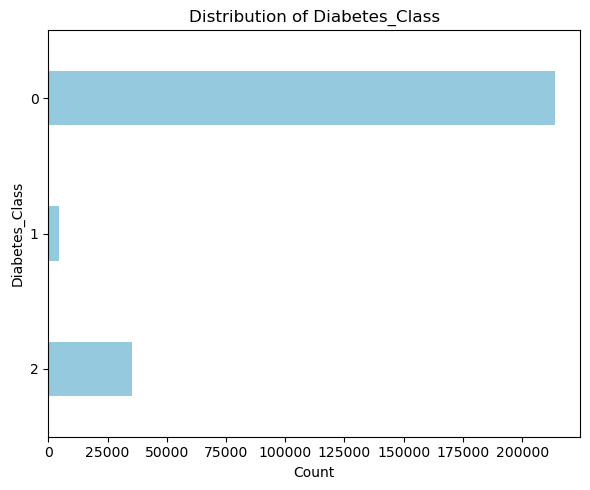

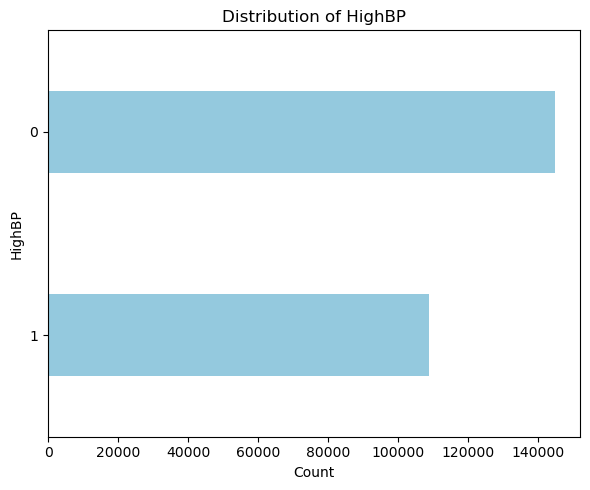

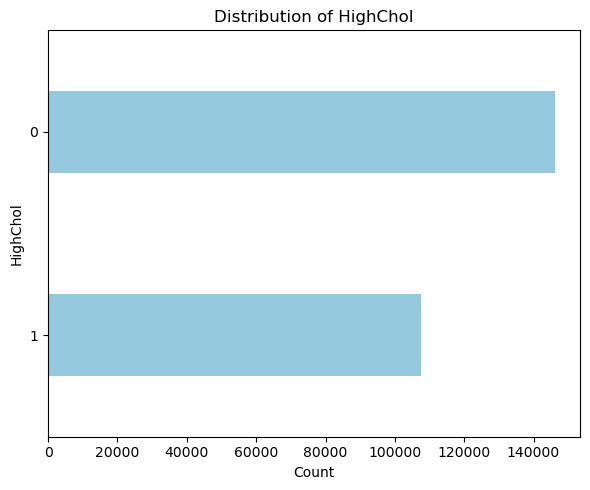

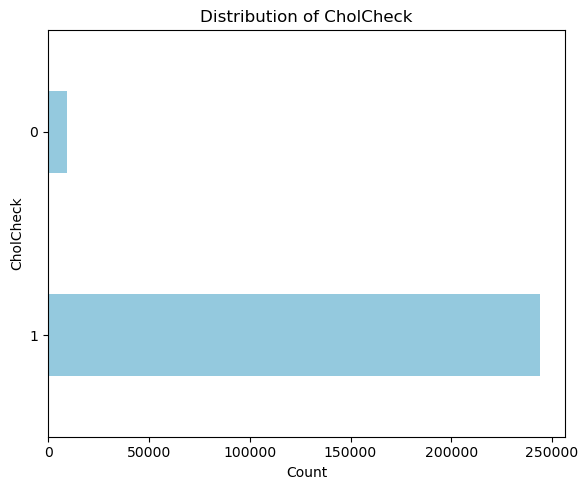

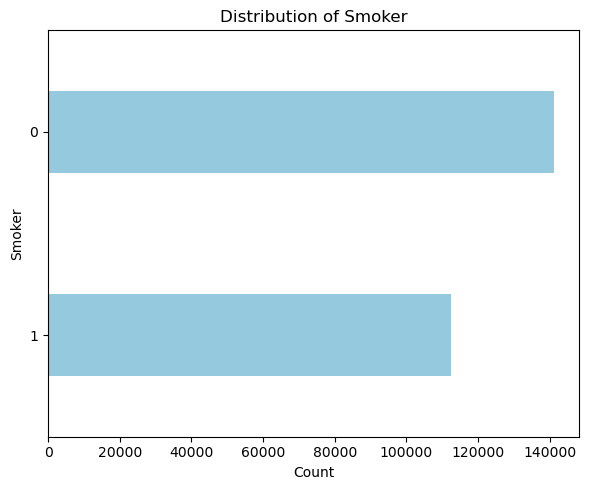

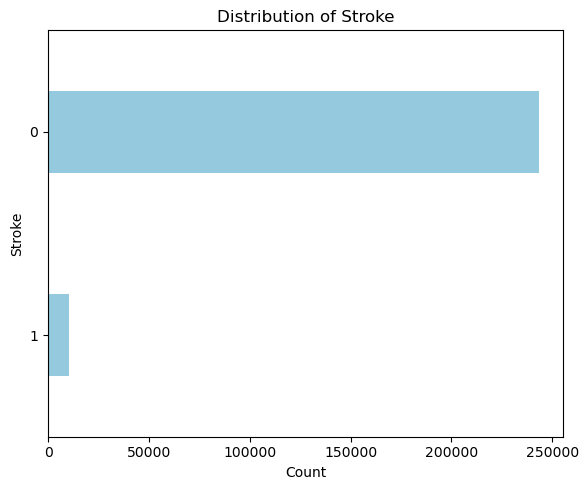

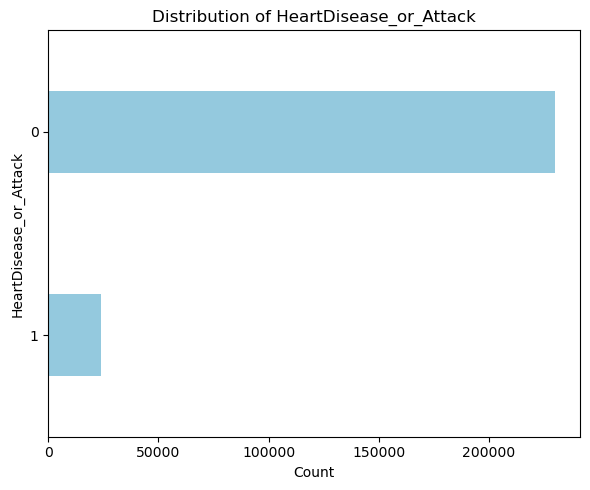

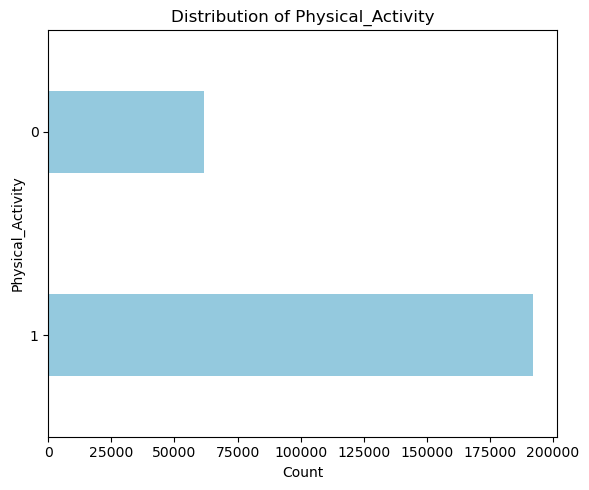

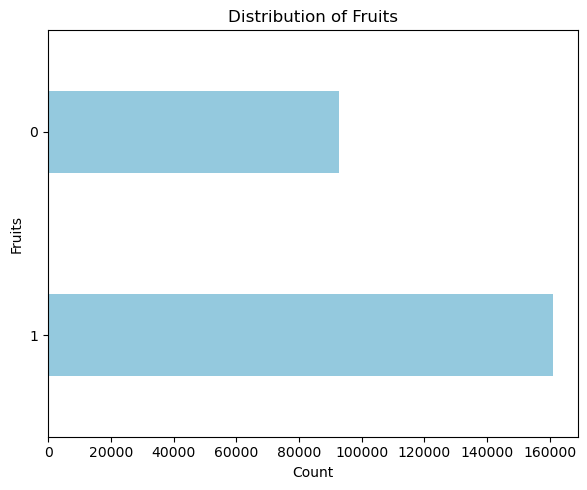

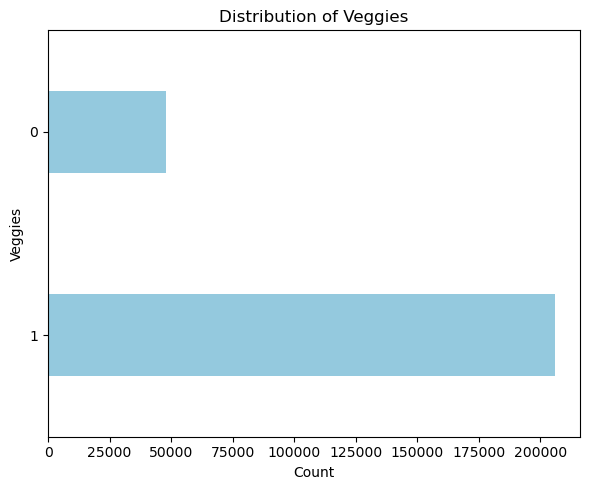

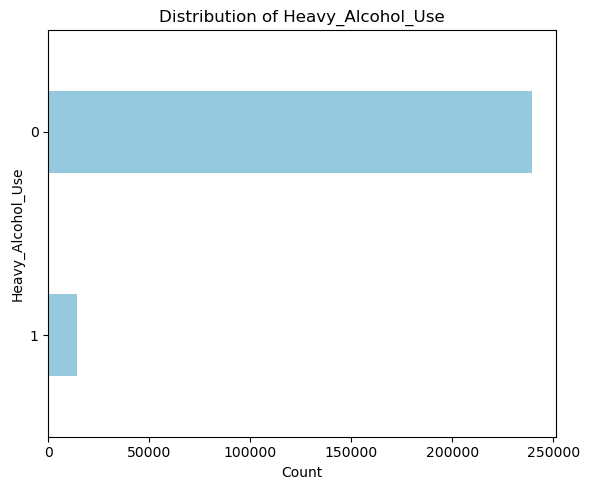

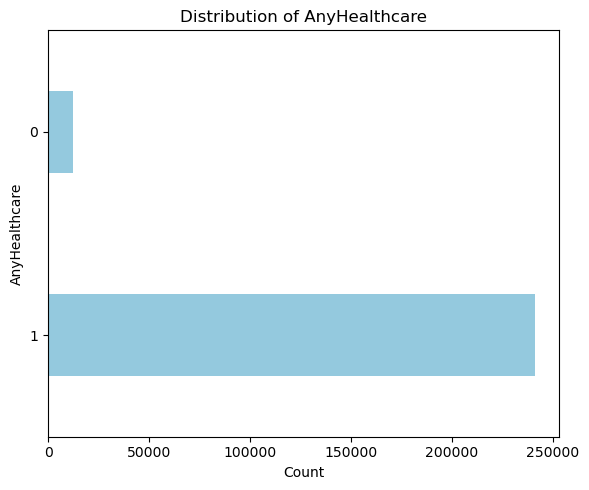

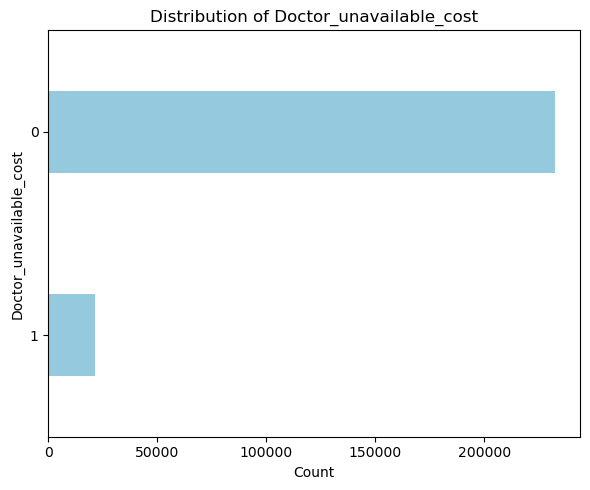

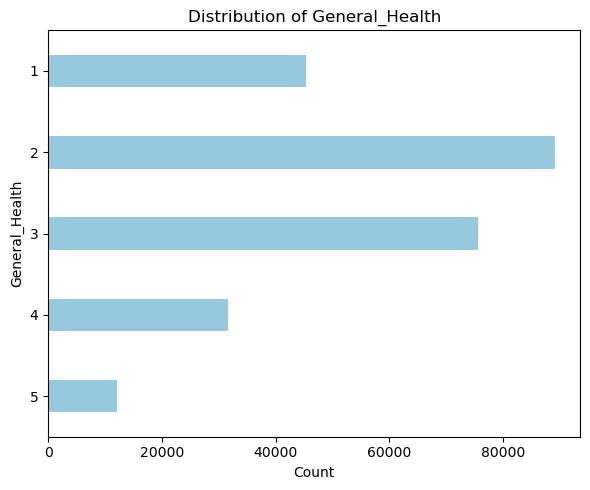

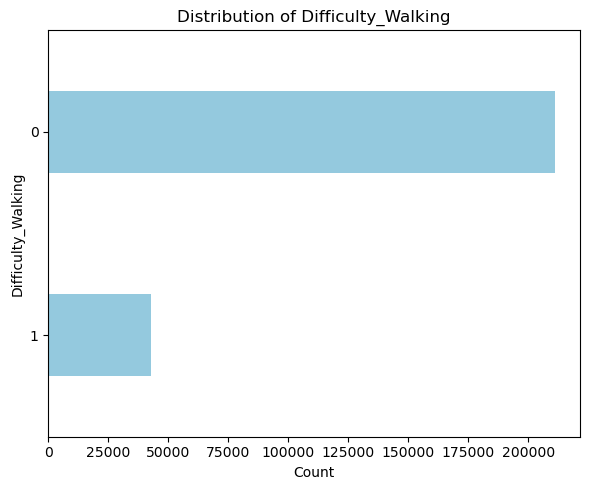

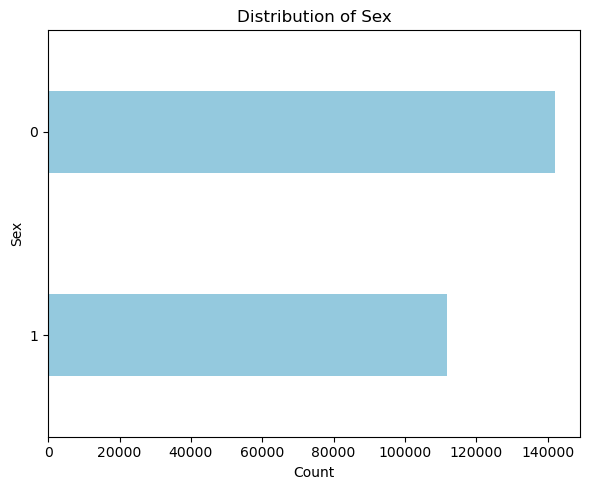

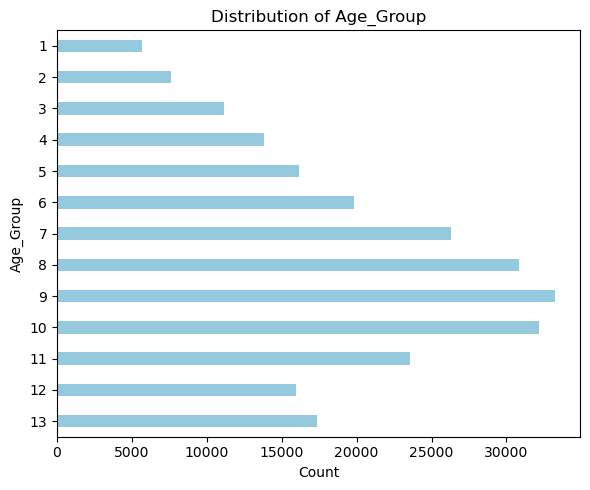

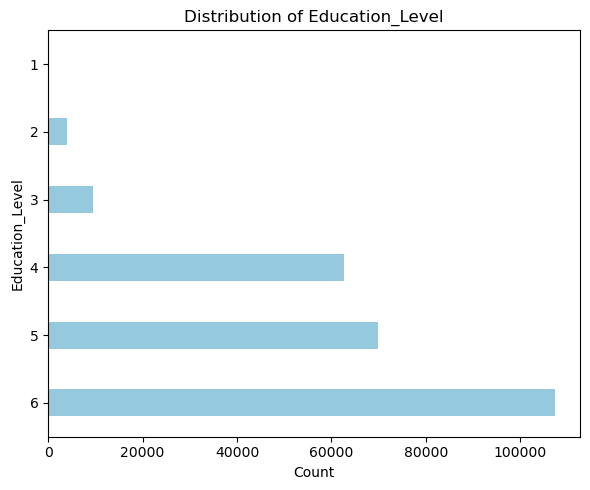

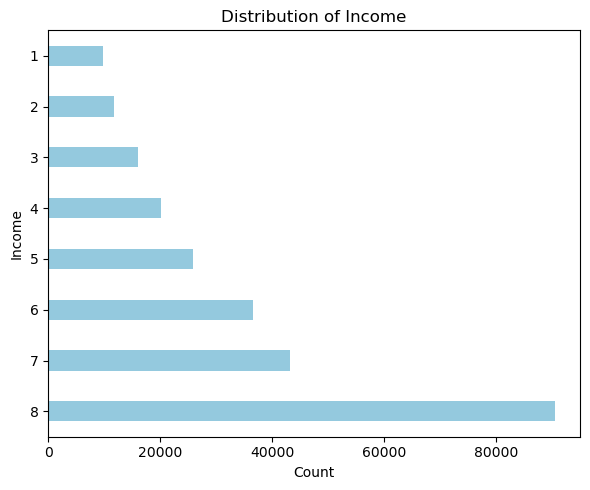

In [21]:
# Plot one by one
for col in ccat:
    plt.figure(figsize=(6,5))
    sns.countplot(data=diabetes_df, y=col, color='skyblue',width=0.4)
    plt.title(f'Distribution of {col}')
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**From these countplots, we can observe the frequency of each category across the dataset. Initially, the target Diabetes_Class contained three distinct classes: No Diabetes (0), Pre-diabetes (1), and Diabetes (2). Given the low representation of pre-diabetic cases, I combined them with diabetic cases to form a binary classification target:**

0: Not Diabetic

1: Diabetic (includes both previously pre-diabetic and diabetic)

This allows us to preserve at-risk individuals and improve the model’s ability to generalize.

In [22]:
diabetes_df.Diabetes_Class.value_counts().sort_index()

Diabetes_Class
0    213703
1      4631
2     35346
Name: count, dtype: int64

In [23]:
# Reclassify both pre-diabetic (1) and diabetic (2) as 1
diabetes_df['Diabetes_Class'] = diabetes_df['Diabetes_Class'].replace({1: 1, 2: 1})

In [24]:
diabetes_df.Diabetes_Class.value_counts().sort_index()

Diabetes_Class
0    213703
1     39977
Name: count, dtype: int64

In [25]:
diabetes_df['Diabetes_Class'].value_counts(normalize=True) * 100

Diabetes_Class
0    84.24117
1    15.75883
Name: proportion, dtype: float64

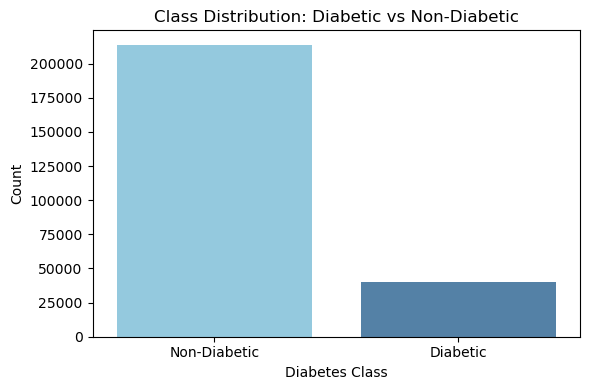

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=diabetes_df, x='Diabetes_Class', palette=['skyblue', 'steelblue'])
plt.title('Class Distribution: Diabetic vs Non-Diabetic')
plt.xlabel('Diabetes Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=["Non-Diabetic", "Diabetic"])
plt.tight_layout()
plt.savefig("class_distribution_1.png", dpi=300, bbox_inches='tight')
plt.show()

In [27]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Class           253680 non-null  int64
 1   HighBP                   253680 non-null  int64
 2   HighChol                 253680 non-null  int64
 3   CholCheck                253680 non-null  int64
 4   BMI                      253680 non-null  int64
 5   Smoker                   253680 non-null  int64
 6   Stroke                   253680 non-null  int64
 7   HeartDisease_or_Attack   253680 non-null  int64
 8   Physical_Activity        253680 non-null  int64
 9   Fruits                   253680 non-null  int64
 10  Veggies                  253680 non-null  int64
 11  Heavy_Alcohol_Use        253680 non-null  int64
 12  AnyHealthcare            253680 non-null  int64
 13  Doctor_unavailable_cost  253680 non-null  int64
 14  General_Health           253680 non-

<a id="summary-univariate-categorical"></a>
### Summary: Univariate Insights — Categorical


| Feature Category          | Features                                      | Insight Summary                                                                 | Action                                                           |
|---------------------------|-----------------------------------------------|----------------------------------------------------------------------------------|------------------------------------------------------------------|
|  Target Variable         | `Diabetes_Class`                              | Imbalanced — most samples are non-diabetic (0)                                  | Balance the dataset (SMOTE, stratified split, undersampling)     |
|  Clinical Risk Factors   | `HighBP`, `HighChol`                          | Large portion have high BP and cholesterol — key diabetes risk factors          | Retain as important features                                     |
|  Lifestyle & Behavior    | `Smoker`                                      | Moderate split; may correlate with other risks                                  | Retain for modeling                                               |
|  Healthcare Access       | `CholCheck`, `AnyHealthcare`                 | Very low variance (almost all have healthcare & recent check)                   | Consider dropping (low predictive power)                          |
|  Serious Conditions      | `Stroke`, `HeartDisease_or_Attack`           | Rare cases but clinically relevant                                               | Keep, possibly apply class weighting or resampling                |
|  Health Habits         | `PhysActivity`, `Fruits`, `Veggies`          | Some show healthy behaviors, others don’t — behavioral risk markers             | Retain — valuable lifestyle predictors                            |
|  Alcohol Use             | `HeavyAlcoholUse`                             | Majority not heavy drinkers; skewed but aligns with risk                         | Retain — may interact with other lifestyle variables              |
|  General Health & Access | `GenHlth`, `Difficulty_Walking`, `Doctor_unavailable_cost` | Reflect health burden and access to care                      | Retain — important for mobility and socioeconomic risks           |
|  Demographics          | `Sex`                                         | Likely balanced; moderate predictor                                              | Retain, but expect modest impact                                  |
|  Socioeconomic Factors   | `Age_Group`, `Education_Level`, `Income`      | Older age, lower income/education associated with higher diabetes risk          | Retain — strong predictive indicators                             |



<a id="multivariate-numerical-vs-target"></a>
### Multivariate (Numerical) vs Target


In [76]:
# Numerical columns to evaluate
ncol = ['Mental_Health', 'Physical_Health', 'BMI']

# Loop through each feature to compare with Diabetes_Class
for col in ncol:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=diabetes_df, x='Diabetes_Class', y=col, color='skyblue')
    plt.title(f'{col} vs Diabetes_Class')
    plt.xlabel('Diabetes Class (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    # Save each figure individually
    plt.savefig(f"{col}_vs_Diabetes_Class.png", dpi=300, bbox_inches='tight')
    plt.close()  # Close the figure to avoid overlap in the loop
   


<a id="summary-multivariate-numerical"></a>
### Summary: Multivariate Insights — Numerical


| Feature          | Observation in Diabetic Group                | Observation in Non-Diabetic Group     | Key Insight                                                                 |
|------------------|-----------------------------------------------|----------------------------------------|------------------------------------------------------------------------------|
| **Mental_Health** | Higher median and wider spread of unhealthy days; more outliers | Lower median and fewer outliers        | Mental health issues are more prevalent among diabetics                    |
| **Physical_Health** | Much higher spread; upper quartile and median are elevated | Lower and tighter distribution         | Physical health declines significantly among diabetic individuals          |
| **BMI**          | Higher median BMI with more extreme values   | Lower median; fewer outliers           | Strong link between higher BMI and diabetes (potential obesity risk factor) |

 These differences reinforce the importance of these features as strong predictors of diabetes status in future modeling.


<a id="multivariate-categorical-vs-target"></a>
### Multivariate (Categorical) vs Target


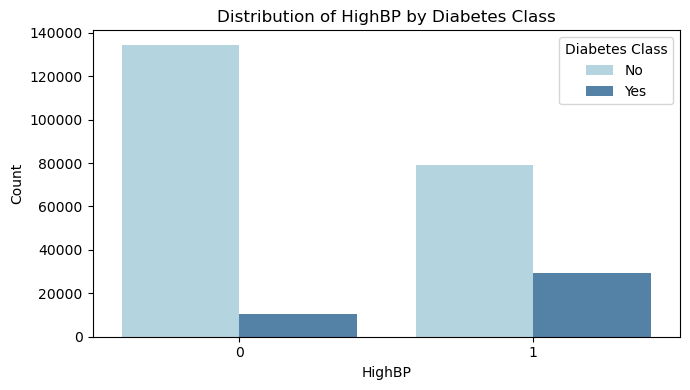

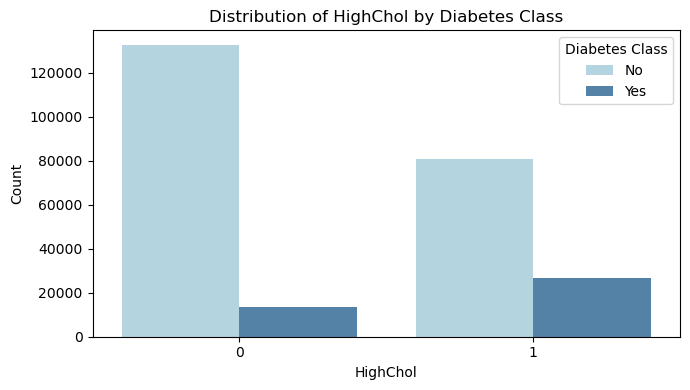

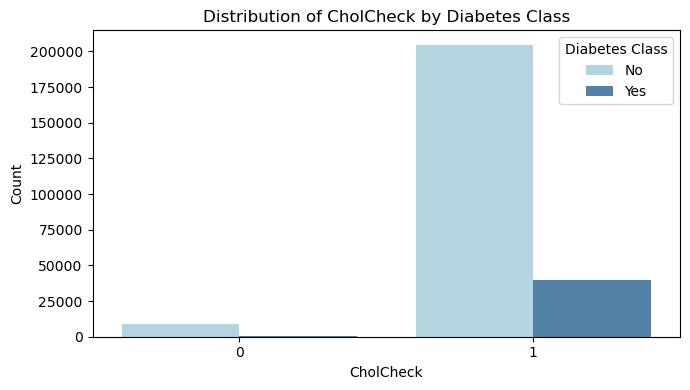

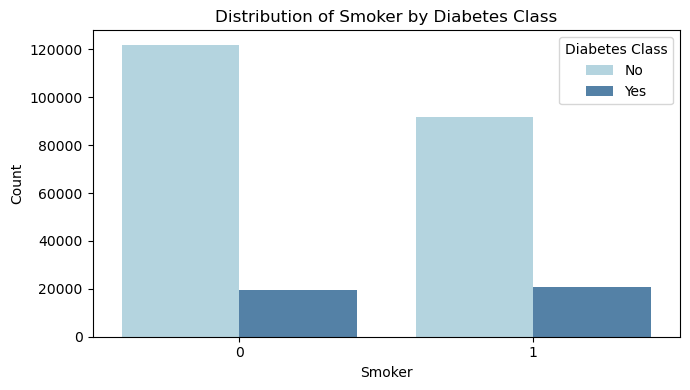

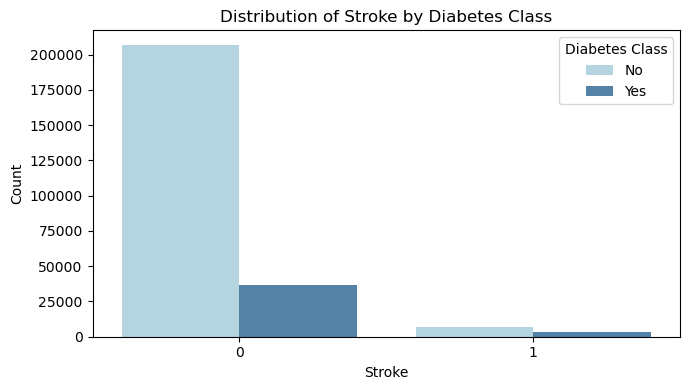

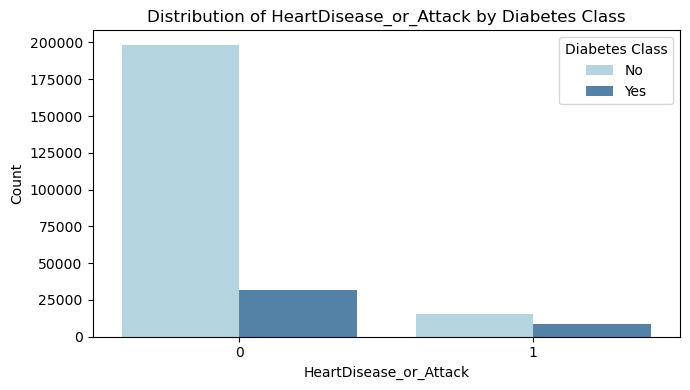

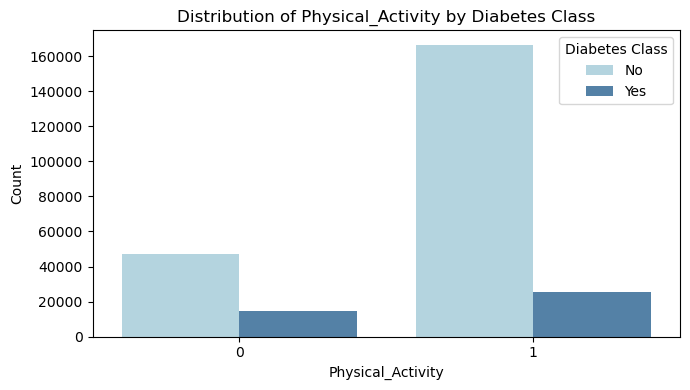

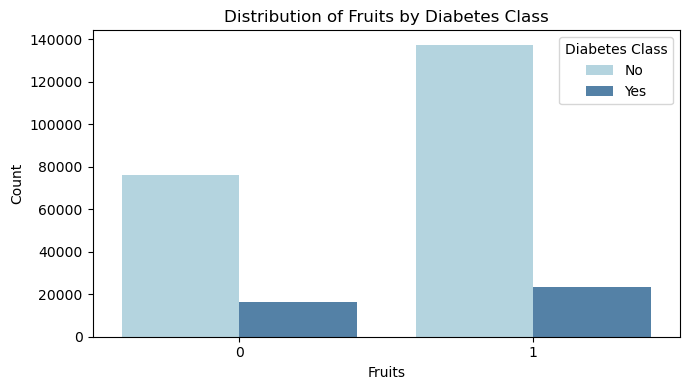

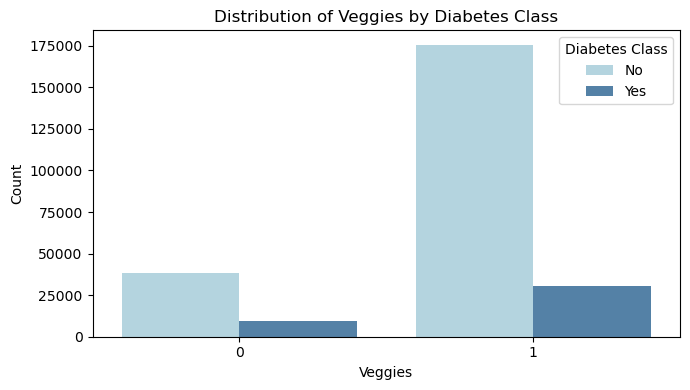

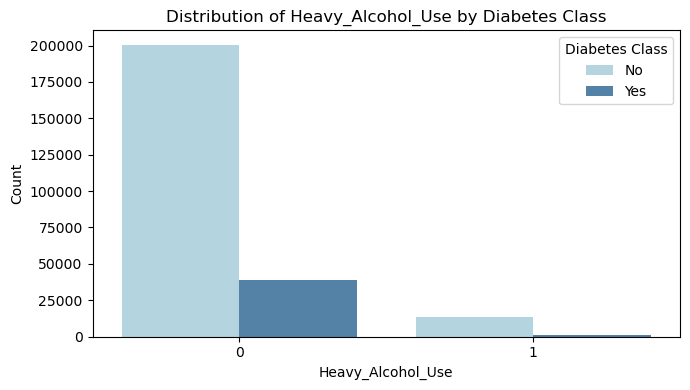

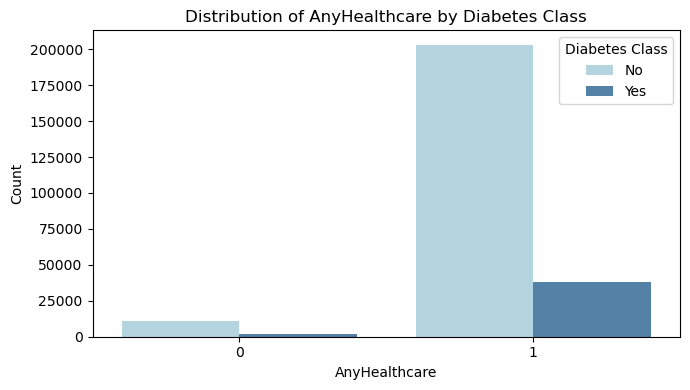

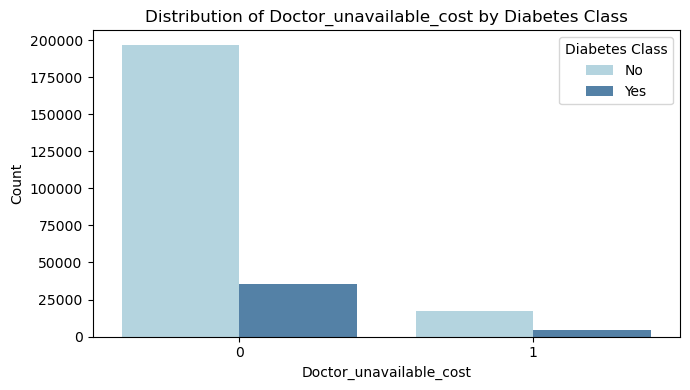

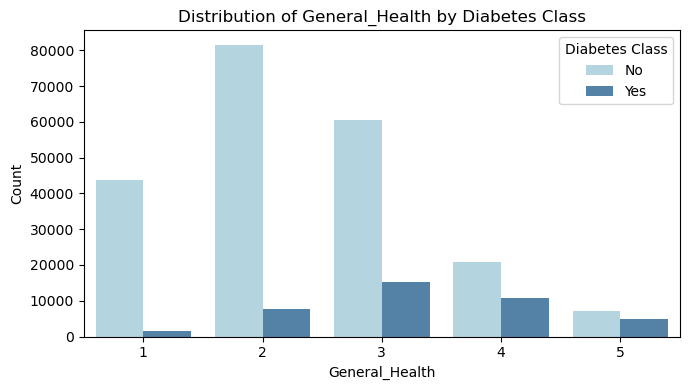

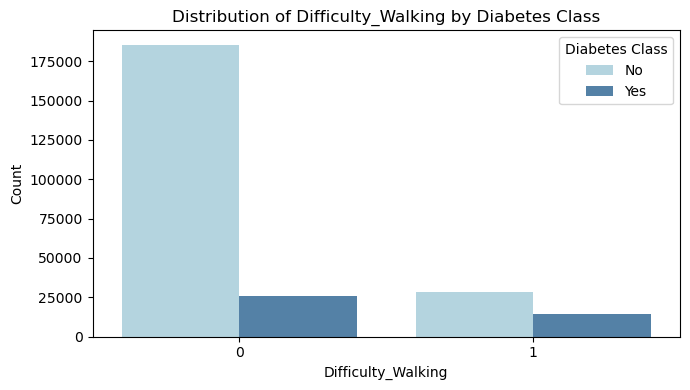

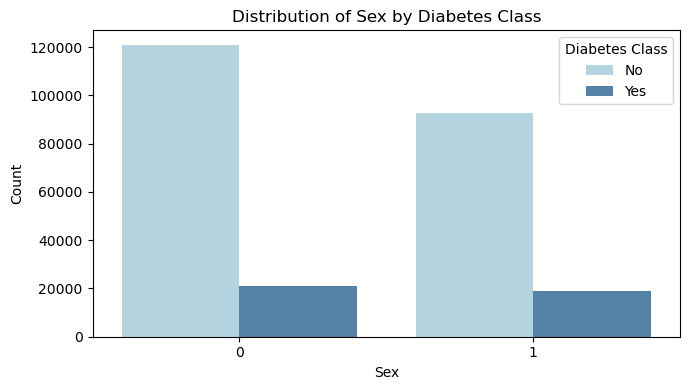

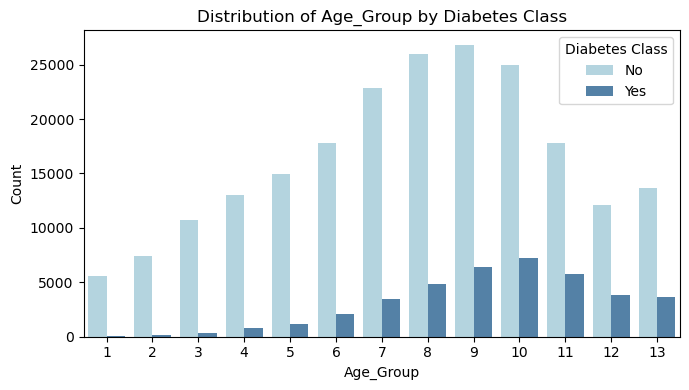

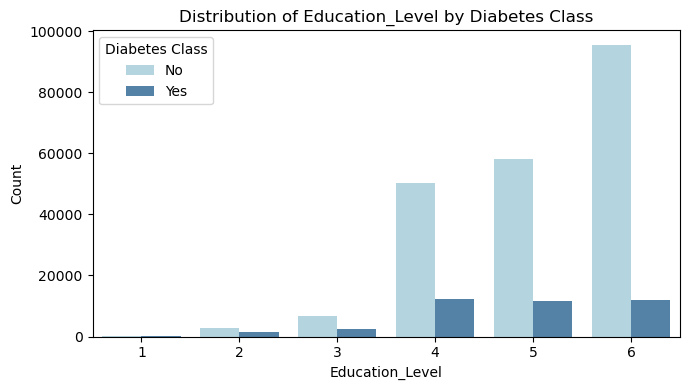

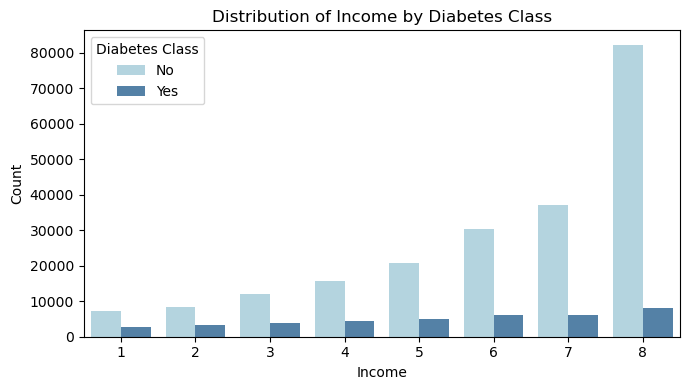

In [29]:
# Categorical columns to analyze (excluding numerical ones)
ncol = ['Mental_Health', 'Physical_Health', 'BMI']
ccat = [col for col in diabetes_df.columns if col not in ncol + ['Diabetes_Class']] #creates a combined list of numerical columns plus target columns and then filters out any column that is not in it and stores in ccat

# Plot grouped bar charts
for col in ccat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=diabetes_df, x=col, hue='Diabetes_Class', palette=['lightblue', 'steelblue'])
    plt.title(f'Distribution of {col} by Diabetes Class')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Diabetes Class", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()


<a id="summary-multivariate-categorical"></a>
### Summary: Multivariate Insights — Categorical


| Feature Category          | Features                                                | Key Insight                                                                   | Actionable Note                                                           |
| ------------------------- | ------------------------------------------------------- | ----------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| **Clinical Risk Factors** | `HighBP`, `HighChol`                                    | Higher rates of diabetes observed among those with high BP and cholesterol    | Strong indicators — retain for modeling                                   |
| **Lifestyle & Behavior**  | `Smoker`, `PhysActivity`, `Fruits`, `Veggies`           | Physical inactivity and low fruit/veggie intake trend higher with diabetes    | Keep — behavioral predictors valuable for intervention                    |
| **Serious Conditions**    | `Stroke`, `HeartDisease_or_Attack`                      | Patients with these conditions show higher diabetes class ratios              | Retain — strong health-related risk markers                               |
| **Healthcare Access**     | `CholCheck`, `AnyHealthcare`, `Doctor_unavailable_cost` | Minor differences; majority have access, but cost concern links with diabetes | Consider retaining `Doctor_unavailable_cost`, drop others if low variance |
| **Demographics**          | `Sex`, `Age_Group`                                      | Older age groups have a higher diabetes rate; sex shows minimal impact        | Retain `Age_Group`; `Sex` may have modest predictive power                |
| **Socioeconomic Factors** | `Education_Level`, `Income`                             | Lower education and income levels correlate with higher diabetes incidence    | Retain — strong predictors of chronic disease risk                        |
| **Mobility & Health**     | `GenHlth`, `Difficulty_Walking`                         | Worse general health and difficulty walking associated with diabetes          | Retain — meaningful mobility and wellness indicators                      |


<a id="feature-engineering-one-hot-encoding"></a>
## Feature Engineering — One-Hot Encoding


Since most of my categorical features are already in binary format (sex, smoker, stroke,highBP etc.) there is no need for one hot encoding. However, for features like age_group, education level and income, there are more than just two outcomes (ranked but not continous), these should be encoded for correlation matrix

 **Encoding Strategy Rationale**
 
To prepare our categorical features for modeling, we used a combination of ordinal encoding and one-hot encoding, based on the nature of each variable:

 **Ordinal Encoding**
 
These variables have a clear and meaningful order where higher values indicate progression (e.g., older age groups, higher education, or income brackets). Ordinal encoding preserves this ranking and enables models to leverage the inherent hierarchy in the data. 
We applied ordinal encoding to the following features:

**Age_Group**

**Education_Level**

**Income**


**One-Hot Encoding**

I applied one-hot encoding to **General_Health**.

Although it appears ordinal (e.g., Excellent to Poor), General_Health is subjective and self-reported, and the intervals between categories are not guaranteed to be consistent or linear. To avoid misleading the model into assuming a numeric relationship that may not exist, we treated it as a nominal variable using one-hot encoding.

This balanced approach ensures we preserve useful structure while avoiding incorrect assumptions about the relationships between categories

In [30]:
# Copy the dataframe so that we can work on that without affecting the original dataframe
df_encoded = diabetes_df.copy()

# Apply ordinal encoding to ordinal features
ordinal_cols = ['Age_Group', 'Education_Level', 'Income']
df_encoded[ordinal_cols] = df_encoded[ordinal_cols].astype(int)  #treating them as ordered intergers, preserving their ordinal structure

# One-hot encode 'General_Health' (still okay since it's not strictly ordinal)
df_encoded = pd.get_dummies(df_encoded, columns=['General_Health'], drop_first=True)


In [31]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Class           253680 non-null  int64
 1   HighBP                   253680 non-null  int64
 2   HighChol                 253680 non-null  int64
 3   CholCheck                253680 non-null  int64
 4   BMI                      253680 non-null  int64
 5   Smoker                   253680 non-null  int64
 6   Stroke                   253680 non-null  int64
 7   HeartDisease_or_Attack   253680 non-null  int64
 8   Physical_Activity        253680 non-null  int64
 9   Fruits                   253680 non-null  int64
 10  Veggies                  253680 non-null  int64
 11  Heavy_Alcohol_Use        253680 non-null  int64
 12  AnyHealthcare            253680 non-null  int64
 13  Doctor_unavailable_cost  253680 non-null  int64
 14  Mental_Health            253680 non-

In [32]:
df_encoded.head()

,Diabetes_Class,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,...,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income,General_Health_2,General_Health_3,General_Health_4,General_Health_5
0,0,1,1,1,40,1,0,0,0,0,...,15,1,0,9,4,3,False,False,False,True
1,0,0,0,0,25,1,0,0,1,0,...,0,0,0,7,6,1,False,True,False,False
2,0,1,1,1,28,0,0,0,0,1,...,30,1,0,9,4,8,False,False,False,True
3,0,1,0,1,27,0,0,0,1,1,...,0,0,0,11,3,6,True,False,False,False
4,0,1,1,1,24,0,0,0,1,1,...,0,0,0,11,5,4,True,False,False,False


In [33]:
df_encoded.describe()

,Diabetes_Class,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,...,Heavy_Alcohol_Use,AnyHealthcare,Doctor_unavailable_cost,Mental_Health,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.157588,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.056197,0.951053,0.084177,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.364355,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.230302,0.215759,0.277654,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


<a id="feature Selection"></a>
## Feature Selection

<a id="correlation-matrix-and-vif"></a>
### Correlation Matrix and VIF


Corrleation Matrix is a useful tool to do a Multi-collinearity scan between all the independent features. It is important to ensure that no 2 collinear columns are being represented or else the results from model will be incorrect. This is because each coefficient should contribute uniquely to the model or else its a double representation and also does not add any new information.

VIF is another tool used to determine feature-target correlation. This gives us a quick sense of which features have the strongest linear association with our target variable.

In [34]:
# Pull out the X and y
X = df_encoded.drop("Diabetes_Class", axis=1)
y = df_encoded["Diabetes_Class"]

In [35]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,Veggies,...,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income,General_Health_2,General_Health_3,General_Health_4,General_Health_5
0,1,1,1,40,1,0,0,0,0,1,...,15,1,0,9,4,3,False,False,False,True
1,0,0,0,25,1,0,0,1,0,0,...,0,0,0,7,6,1,False,True,False,False
2,1,1,1,28,0,0,0,0,1,0,...,30,1,0,9,4,8,False,False,False,True
3,1,0,1,27,0,0,0,1,1,1,...,0,0,0,11,3,6,True,False,False,False
4,1,1,1,24,0,0,0,1,1,1,...,0,0,0,11,5,4,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,5,0,1,5,6,7,False,True,False,False
253676,1,1,1,18,0,0,0,0,0,0,...,0,1,0,11,2,4,False,False,True,False
253677,0,0,1,28,0,0,0,1,1,0,...,0,0,0,2,5,2,False,False,False,False
253678,1,0,1,23,0,0,0,0,1,1,...,0,0,1,7,5,1,False,True,False,False


In [36]:
X.shape

(253680, 24)

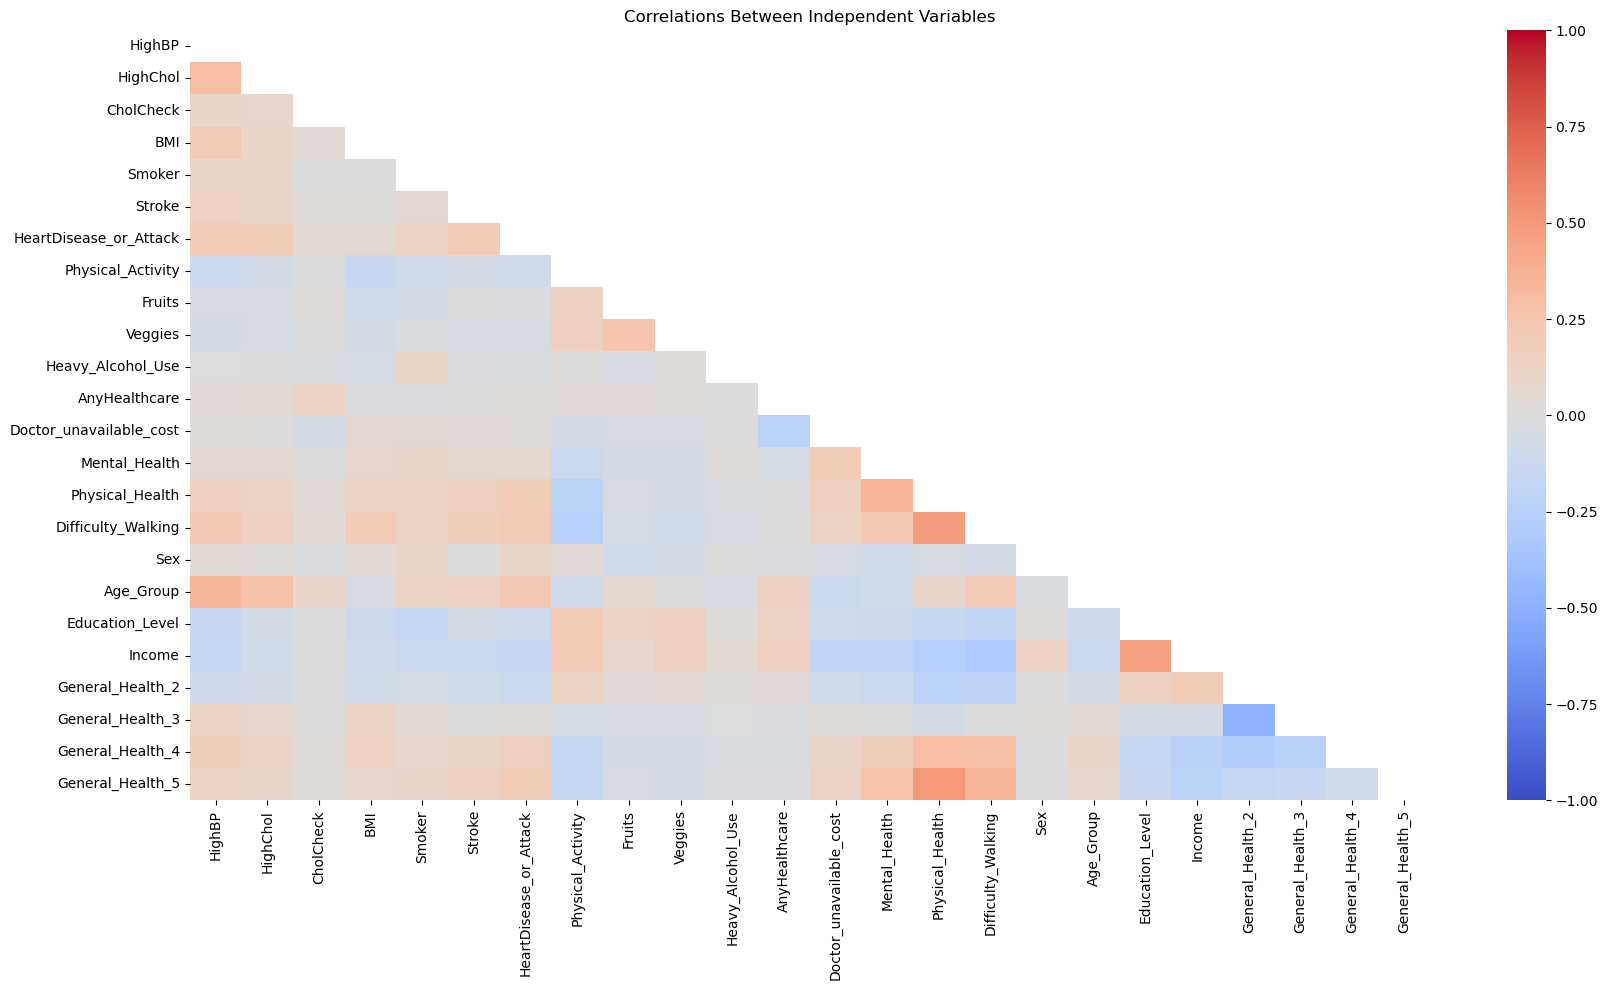

In [37]:
# Calculate all the correlations between each independent variable
corr_df = X.corr(numeric_only=True)

# Mask for upper-triangular
mask = np.triu(corr_df)

# Visualize with seaborn
plt.figure(figsize=(20, 10))
sns.heatmap(
    corr_df, 
    annot=True,
    fmt=".2f",
    annot_kws={"size": 20},
    vmax=1, 
    vmin=-1, 
    center=0, 
    cmap="coolwarm", 
    mask=mask
)

plt.title("Correlations Between Independent Variables")
plt.show()

Here, we can see that **no features shows high correlation with each other and thus no "multi-collinearity" issues detected**.

We can also see **how strongly does each feature relate to the target variable**

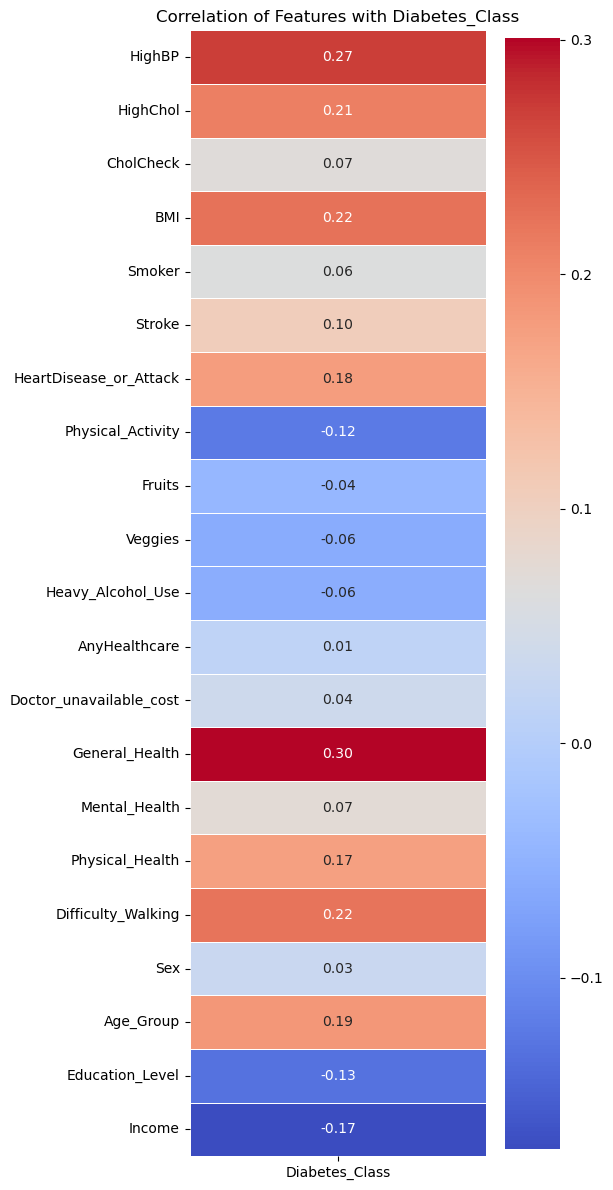

In [38]:
corr_matrix = diabetes_df.corr(numeric_only=True)
target_corr = corr_matrix[['Diabetes_Class']].drop('Diabetes_Class')
plt.figure(figsize=(6, 12))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation of Features with Diabetes_Class")
plt.tight_layout()
plt.show()

The strongest correlations are : **General_Health, HighBP, Difficulty_Walking, and BMI** — all of which are positively correlated with diabetes

Some features show weak or negligible correlation (e.g., Fruits, Veggies, Doctor_unavailable_cost), which may not contribute significantly to prediction

Detecting Multicollinearity With **Variance Inflation Factors (VIF)**

VIF is another technique to see how the features variance explain about the target variable.

In [39]:
# Adding the constant to the features 
X_with_const = sm.add_constant(X)
X_with_const = X_with_const.astype(float)

In [40]:
VIF_values = pd.Series(
    data=[variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])],
    index=X_with_const.columns
)

VIF_values[1:] # Slicing to leave out the constant

HighBP                     1.333368
HighChol                   1.174198
CholCheck                  1.032827
BMI                        1.145879
Smoker                     1.092455
Stroke                     1.082878
HeartDisease_or_Attack     1.177986
Physical_Activity          1.157560
Fruits                     1.112948
Veggies                    1.112456
Heavy_Alcohol_Use          1.024076
AnyHealthcare              1.113248
Doctor_unavailable_cost    1.144274
Mental_Health              1.244852
Physical_Health            1.797809
Difficulty_Walking         1.556660
Sex                        1.075711
Age_Group                  1.350725
Education_Level            1.327206
Income                     1.507942
General_Health_2           1.983224
General_Health_3           2.152027
General_Health_4           2.119112
General_Health_5           1.978818
dtype: float64

A high VIF means that the independent variable in question has a higher level of multi-collinearity with the other independent variables.

An obvious step would be to just drop the columns with the highest VIF numbers. One thing to note however is that dropping one variable will change the VIFs for *all the independent variables*.

For our case, as we see above **none of our remaining variables has a VIF greater then 5 (common cut-off) and that all are significant and not multi-collinear. This means we can now proceed towards modeling**.

<a id="hypothesis-testing"></a>
## Hypothesis Testing


<a id="chi-squared-test"></a>
### Chi-Squared Test (Independence)


$$H_0: \text{There is no relationship between features and Diabetes_Class} \;\; vs \;\;  H_1: \text{There is a relationship between features and Diabetes_Class.}$$

This test only applies to categorical features to assess whether their distribution differs significantly between the diabetes and non-diabetes groups

I have selected a typical threshold of 0.05 for the p-value to determine its significance.

A **p-value < 0.05** suggests a statistically significant association, meaning the feature is likely to provide useful information for prediction. A high p-value suggests little evidence of association, and the feature may be less informative for the model.


In [41]:
chi2_results = []

for col in df_encoded.columns:
    if col != 'Diabetes_Class' and df_encoded[col].nunique() <= 20:
        # Create contingency table
        contingency = pd.crosstab(df_encoded[col], df_encoded['Diabetes_Class'])
        
        # Run chi-squared test
        chi2, p,_,_  = chi2_contingency(contingency)
        
        # Store all results
        chi2_results.append((col, chi2, p))

# Convert to DataFrame for easy viewing
chi2_df = pd.DataFrame(chi2_results, columns=['Feature', 'Chi2_statistic', 'p_value'])
print(chi2_df)

                    Feature  Chi2_statistic        p_value
0                    HighBP    18537.573861   0.000000e+00
1                  HighChol    11217.003933   0.000000e+00
2                 CholCheck     1167.849165  5.924497e-256
3                    Smoker      999.414764  2.406995e-219
4                    Stroke     2784.703927   0.000000e+00
5    HeartDisease_or_Attack     7939.890468   0.000000e+00
6         Physical_Activity     3737.448802   0.000000e+00
7                    Fruits      449.122744   1.119518e-99
8                   Veggies      889.218416  2.165824e-195
9         Heavy_Alcohol_Use      814.373948  4.045205e-179
10            AnyHealthcare       50.106706   1.456086e-12
11  Doctor_unavailable_cost      366.429302   1.121130e-81
12       Difficulty_Walking    12518.187461   0.000000e+00
13                      Sex      222.184913   3.018623e-50
14                Age_Group     9539.411674   0.000000e+00
15          Education_Level     4541.124351   0.000000e+

Since all the p-values are below <0.05, we can **reject the null hypothesis and say that there is a relationship between features and diabetes class**. In other words, a statistically significant association between each feature and diabetes status exists.

<a id="two-sample-unpaired-t-test"></a>
### Two-Sample Unpaired t-Test


t-tests compare the means of a continuous variable between two groups (diabetic vs non-diabetic). I have selected a typical threshold of 0.05 for the p-value to determine its significance.

I performed a two-sample unpaired t-test for all the numerical features to compare the means of BMI, Mental Health, and Physical Health between diabetic and non-diabetic individuals and check for significance.

$$H_0: \text{Mean of features are same for both classes} \;\; vs \;\;  H_1: \text{Mean of features are different for both classes.}$$




In [42]:
# Choose numerical features
num_features = ['BMI', 'Mental_Health', 'Physical_Health']
t_test_results = []

for col in num_features:
    group0 = df_encoded[df_encoded['Diabetes_Class'] == 0][col]
    group1 = df_encoded[df_encoded['Diabetes_Class'] == 1][col]
    t_stat, p_val = ttest_ind(group0, group1, equal_var=True)  
    t_test_results.append((col, p_val))

t_test_df = pd.DataFrame(t_test_results, columns=['Feature', 't-test_p_value'])
print(t_test_df)


           Feature  t-test_p_value
0              BMI             0.0
1    Mental_Health             0.0
2  Physical_Health             0.0


There is a statistically significant difference in BMI, mental health days, and physical health days between diabetic and non-diabetic individuals. 



All **p-values were < 0.05**, so we reject the null hypothesis for each variable. These results indicate that **BMI, mental health, and physical health** significantly differ between diabetic and non-diabetic groups and thus may carry significant information useful for distinguishing the classes.

**Please note: Statistical significance is not necessary always equal to predictive importance. There could be some features which are significantly associated with the target variable but still may not have high predictive power**

<a id="summary-feature-significance"></a>
### Summary: Feature Significance



| Feature                  | Test Used   | p-value   | Significant (p < 0.05)? | Remarks                                                      |
|--------------------------|-------------|-----------|-------------------------|--------------------------------------------------------------|
| HighBP                   | Chi-square  | 0.0000    | Yes                     | Strong association with diabetes status                      |
| HighChol                 | Chi-square  | 0.0000    | Yes                     |                                                              |
| CholCheck                | Chi-square  | 0.0000    | Yes                     |                                                              |
| Smoker                   | Chi-square  | 0.0000    | Yes                     |                                                              |
| Stroke                   | Chi-square  | 0.0000    | Yes                     |                                                              |
| HeartDisease_or_Attack   | Chi-square  | 0.0000    | Yes                     |                                                              |
| Physical_Activity        | Chi-square  | 0.0000    | Yes                     |                                                              |
| Fruits                   | Chi-square  | 0.0000    | Yes                     |                                                              |
| Veggies                  | Chi-square  | 0.0000    | Yes                     |                                                              |
| Heavy_Alcohol_Use        | Chi-square  | 0.0000    | Yes                     |                                                              |
| AnyHealthcare            | Chi-square  | 0.0000    | Yes                     |                                                              |
| Doctor_unavailable_cost  | Chi-square  | 0.0000    | Yes                     |                                                              |
| Difficulty_Walking       | Chi-square  | 0.0000    | Yes                     |                                                              |
| Sex                      | Chi-square  | 0.0000    | Yes                     |                                                              |
| Age_Group                | Chi-square  | 0.0000    | Yes                     | Diabetes prevalence rises with age; highest in older groups  |
| Education_Level          | Chi-square  | 0.0000    | Yes                     |                                                              |
| Income                   | Chi-square  | 0.0000    | Yes                     |                                                              |
| General_Health_2         | Chi-square  | 0.0000    | Yes                     |                                                              |
| General_Health_3         | Chi-square  | 0.0000    | Yes                     |                                                              |
| General_Health_4         | Chi-square  | 0.0000    | Yes                     |                                                              |
| General_Health_5         | Chi-square  | 0.0000    | Yes                     |                                                              |
| BMI                      | t-test      | 0.0000    | Yes                     | Mean BMI differs significantly                              |
|


In [43]:
#Saving the Datafile up to encoding and pre-processing

df_encoded.to_csv('diabetes_encoded.csv', index=False)
diabetes_df.to_csv('diabetes_cleaned.csv', index=False)

In [44]:
df_encoded.to_csv("diabetes_dataset_for_tableau.csv", index=False)

<a id="advanced-eda"></a>
## Advanced EDA


Let us try to gather deeper insights between two features in relation to each other. We can look at the lifestyle and socio-economic factors and see if there is a pattern.

The following visualizations present patterns and associations observed in the dataset. They are descriptive in nature and do not imply causation. Differences between groups may be influenced by other unmeasured or uncontrolled factors (e.g., age, lifestyle, socioeconomic status, genetics). These findings should not be interpreted as evidence that one variable directly causes another. Further statistical analysis and controlled studies would be required to establish causal relationships.

<a id="hbp-vs-cholesterol-by-diabetes"></a>
### High Blood Pressure vs High Cholesterol by Diabetes Class


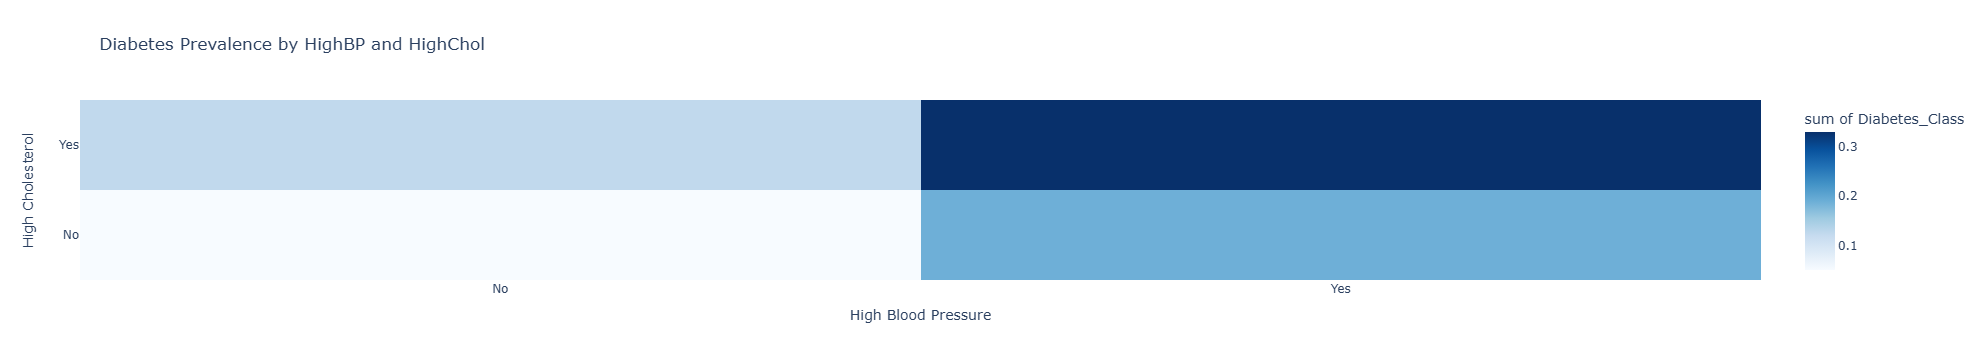

In [45]:
heatmap_data = diabetes_df.groupby(['HighBP', 'HighChol'])['Diabetes_Class'].mean().reset_index() #trying to groupby HighBP and HighChol in a heatmap_data. Computing mean of diabetes class to get the prevalance in that particular combination. 
# Reset index turns the grouped result back into a normal dataframe

fig = px.density_heatmap(  #using plotly heatmap
    heatmap_data,
    x='HighBP',
    y='HighChol',
    z='Diabetes_Class',
    color_continuous_scale='Blues',
    title='Diabetes Prevalence by HighBP and HighChol'
)

fig.update_layout(
    xaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['No', 'Yes']), #shows ticks only for 0 and 1 and replace them with tick text as No/yes
    yaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['No', 'Yes']),
    xaxis_title='High Blood Pressure',
    yaxis_title='High Cholesterol'
)

**Observations**

X-axis: High Blood Pressure (0 = No, 1 = Yes)

Y-axis: High Cholesterol Level (0 = No, 1 = Yes)

Color intensity represents the percentage of people with diabetes in each group.

Mean was used instead of counts so the values represent proportions (percentage with diabetes), making group comparisons independent of sample size.

Insights:

HighBP = Yes, HighChol = Yes ; Around **30% have diabetes (highest risk group)**.

HighBP = Yes, HighChol = No ; Around 20% have diabetes.

HighBP = No, HighChol = Yes ; Around 10% have diabetes.

**HighBP = No, HighChol = No ; Lowest risk group**

Medical studies have shown that people who have high BP and high cholestrol have a direct link to lower blood circulation flow and thus affect the insulin delivery to the cells and thus cause diabetes.
Both these parameters are known to cause metabolic issues and that can complement to causing diabetes.


<a id="physical-activity-vs-smoker-by-diabetes"></a>
### Physical Activity vs Smoker by Diabetes Class


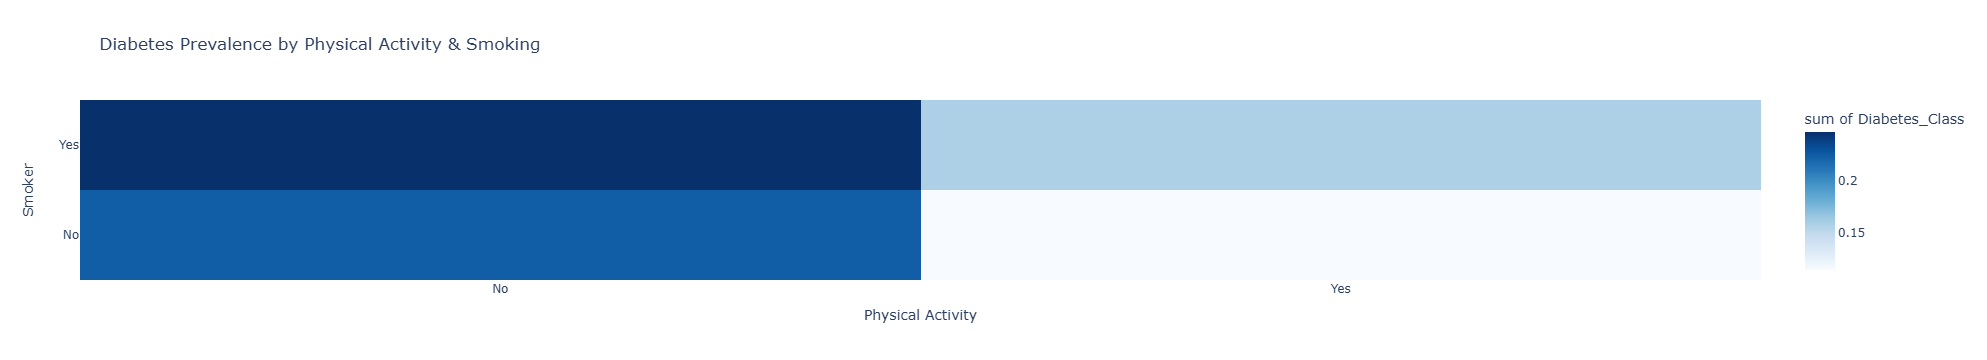

In [46]:
heatmap_data = diabetes_df.groupby(['Physical_Activity', 'Smoker'])['Diabetes_Class'].mean().reset_index()  #trying to groupby Physical Activity & Smoker in a heatmap_data. Computing mean of diabetes class to get the prevalance in that particular combination. 
# Reset index turns the grouped result back into a normal dataframe

fig = px.density_heatmap(     #using a density heatmap from plotly to show the differnet combinations with the prevelance by shade
    heatmap_data,
    x='Physical_Activity',
    y='Smoker',
    z='Diabetes_Class',
    color_continuous_scale='Blues',
    title='Diabetes Prevalence by Physical Activity & Smoking'
)

fig.update_layout(
    xaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['No', 'Yes']), #shows ticks only for 0 and 1 and replace them with tick text as No/yes
    yaxis=dict(tickmode='array', tickvals=[0, 1], ticktext=['No', 'Yes']),
    xaxis_title='Physical Activity',
    yaxis_title='Smoker'
)

fig.show()


**Observations**

X-axis: Physical Activity (0 = No, 1 = Yes)

Y-axis: Smoker (0 = No, 1 = Yes)

Color intensity represents the percentage of people with diabetes in each group.

Mean was used instead of counts so the values represent proportions (percentage with diabetes), which allows for comparison between groups regardless of their size.

Insights:

Smoker = Yes, Physical Activity = No  ; Around 24% have diabetes (highest risk group).

Smoker = No, Physical Activity = No ; Around 22% have diabetes.

Smoker = Yes, Physical Activity = Yes ; Around 15% have diabetes.

**Smoker = No, Physical Activity = Yes ; Around 11% have diabetes (lowest risk group)**.

Medically it is known that people who are smokers and have no physical activity are most prone to diabetes. Nicotine is known to increase insulin resistance and inflammation. Exercising is known to ensure that glucose is being utilized properly rather than just sitting in the bloodstream.

These two indicators are compounding effect to cause diabetes.

<a id="education-vs-income-by-diabetes"></a>
### Education Level vs Income by Diabetes Class


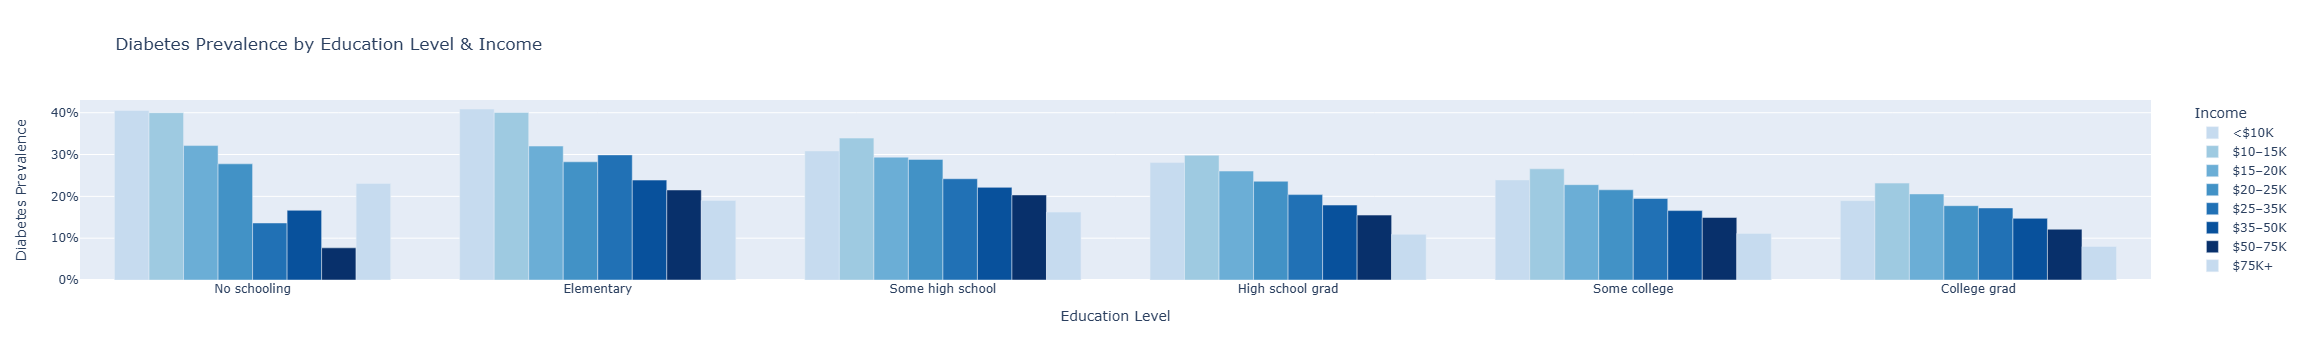

In [77]:
# Map labels
education_labels = {
    '1': 'No schooling', 
    '2': 'Elementary', 
    '3': 'Some high school', 
    '4': 'High school grad', 
    '5': 'Some college', 
    '6': 'College grad'
}

income_labels = {
    '1': '<$10K', 
    '2': '$10–15K', 
    '3': '$15–20K', 
    '4': '$20–25K', 
    '5': '$25–35K', 
    '6': '$35–50K', 
    '7': '$50–75K', 
    '8': '$75K+'
}

# Apply mapping to new columns for display
edu_income['Education_Label'] = edu_income['Education_Level'].astype(str).map(education_labels)
edu_income['Income_Label'] = edu_income['Income'].map(income_labels)

# Plot with labels
fig1 = px.bar(
    edu_income,
    x='Education_Label',
    y='Diabetes_Class',
    color='Income_Label',
    barmode='group',
    labels={'Diabetes_Class': 'Diabetes Prevalence', 'Education_Label': 'Education Level', 'Income_Label': 'Income'},
    title='Diabetes Prevalence by Education Level & Income',
    color_discrete_sequence=custom_blues
)

fig1.update_yaxes(tickformat=".0%")  # Show % format
fig1.show()


**Observations**

X-axis: Education Level (No schooling to College grad)

Color legend: Income category (<10k to 75k+)

The bar height represents the percentage of people with diabetes in each group.

Mean was used instead of counts so the values represent proportions (percentage with diabetes), which allows for comparison between groups regardless of their size.

**Insights**:

Across all education levels, lower income groups (Income = 1–2) have higher diabetes prevalence than higher income groups.

Diabetes prevalence generally decreases as education level increases, especially for lower income categories.

The highest prevalence is observed in low education + low income groups.

**The lowest prevalence is observed in high education + high income groups, suggesting combined protective effects of education and income**

The reason for people who are highly educated and have higher income have least amount of diabates is because they might have more access to knowledge/information on what necessary steps to take to keep healthy. Also, due to better income, they might have better access to healthcare coverage and better opportunity to support a healthier lifestyle (gym, diet etc.)

<a id="fruits-vs-veggies-by-diabetes"></a>
### Fruits vs Veggies by Diabetes Class


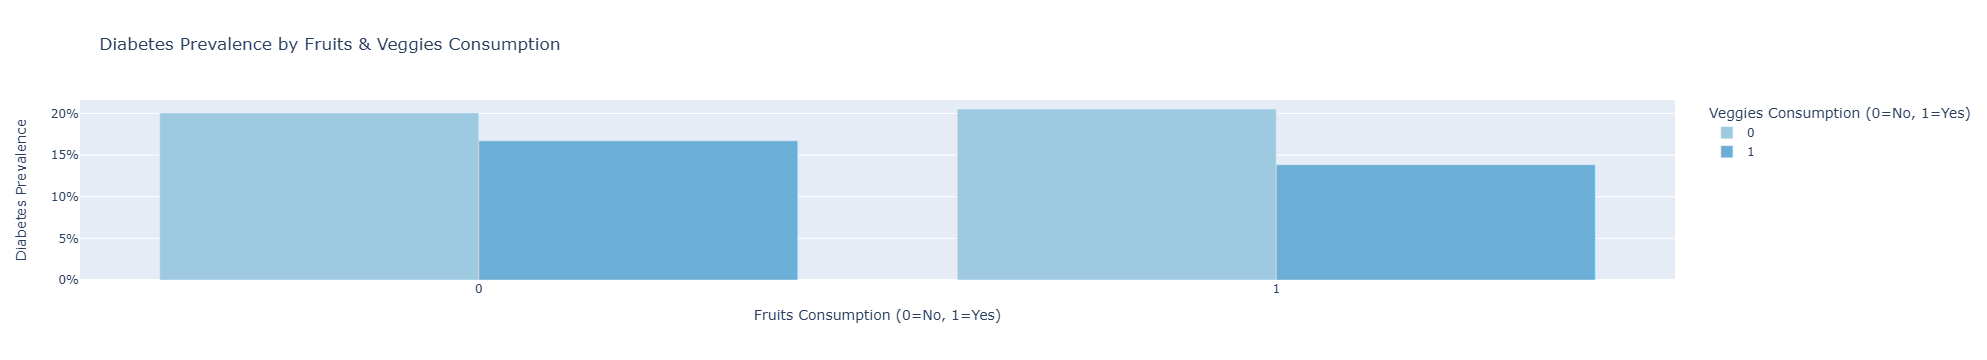

In [48]:
# Group and calculate prevalence
fruit_veg = diabetes_df.groupby(['Fruits', 'Veggies'])['Diabetes_Class'].mean().reset_index()  #trying to groupby fruits and veggies and storing it in fruit_veg table. Computing mean of diabetes class to get the prevalance in that particular combination

# Convert Veggies to string for discrete coloring
fruit_veg['Veggies'] = fruit_veg['Veggies'].astype(str)    #converting the numerical variable to string to get a legend with two colors instead of continous color bar

# Plot grouped bar
fig = px.bar(
    fruit_veg,
    x='Fruits',
    y='Diabetes_Class',
    color='Veggies',
    barmode='group',  #show side by side bar
    labels={
        'Diabetes_Class': 'Diabetes Prevalence',
        'Fruits': 'Fruits Consumption (0=No, 1=Yes)',
        'Veggies': 'Veggies Consumption (0=No, 1=Yes)'
    },
    title='Diabetes Prevalence by Fruits & Veggies Consumption',
    color_discrete_sequence=px.colors.sequential.Blues[3:]   #skipping the first 3 shades of blue and then using blue gradient scheme
)

# Format y-axis as percentage
fig.update_yaxes(tickformat=".0%") #formats the y-axis as percentage instead of 0.10

fig.show()


**Observations**

X-axis: Fruits Consumption (0 = No, 1 = Yes)

Color legend: Veggies Consumption (0 = No, 1 = Yes)

The bar height represents the percentage of people with diabetes in each group.

Mean was used instead of counts so the values represent proportions (percentage with diabetes), allowing comparison between groups regardless of their size.

Insights

Fruits = No, Veggies = No ; Moderate diabetes prevalence (~20%).

Fruits = Yes, Veggies = No ; Highest prevalence (~21%).

Fruits = No, Veggies = Yes ; Slightly lower prevalence (~17%).

**Fruits = Yes, Veggies = Yes ; Lowest prevalence (~14%), suggesting that combined daily fruit and vegetable intake is associated with the lowest diabetes risk**.

Medical studies have shown that having regular intake of fruits and vegetables is a part of a healty diet and thus can help curb diabetes.

It is also important to note that people who have fruits and NO vegetables, have highest diabetes because, fruits has natural sugars and if they dont balance it with veggies, the overall effect reducing blood sugar isnt strong. Veggies are known to improve insulin sensitivity and glucose absorption.


In [49]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Class           253680 non-null  int64
 1   HighBP                   253680 non-null  int64
 2   HighChol                 253680 non-null  int64
 3   CholCheck                253680 non-null  int64
 4   BMI                      253680 non-null  int64
 5   Smoker                   253680 non-null  int64
 6   Stroke                   253680 non-null  int64
 7   HeartDisease_or_Attack   253680 non-null  int64
 8   Physical_Activity        253680 non-null  int64
 9   Fruits                   253680 non-null  int64
 10  Veggies                  253680 non-null  int64
 11  Heavy_Alcohol_Use        253680 non-null  int64
 12  AnyHealthcare            253680 non-null  int64
 13  Doctor_unavailable_cost  253680 non-null  int64
 14  General_Health           253680 non-

<a id="age-vs-sex-by-diabetes"></a>
### Age vs Sex by Diabetes Class


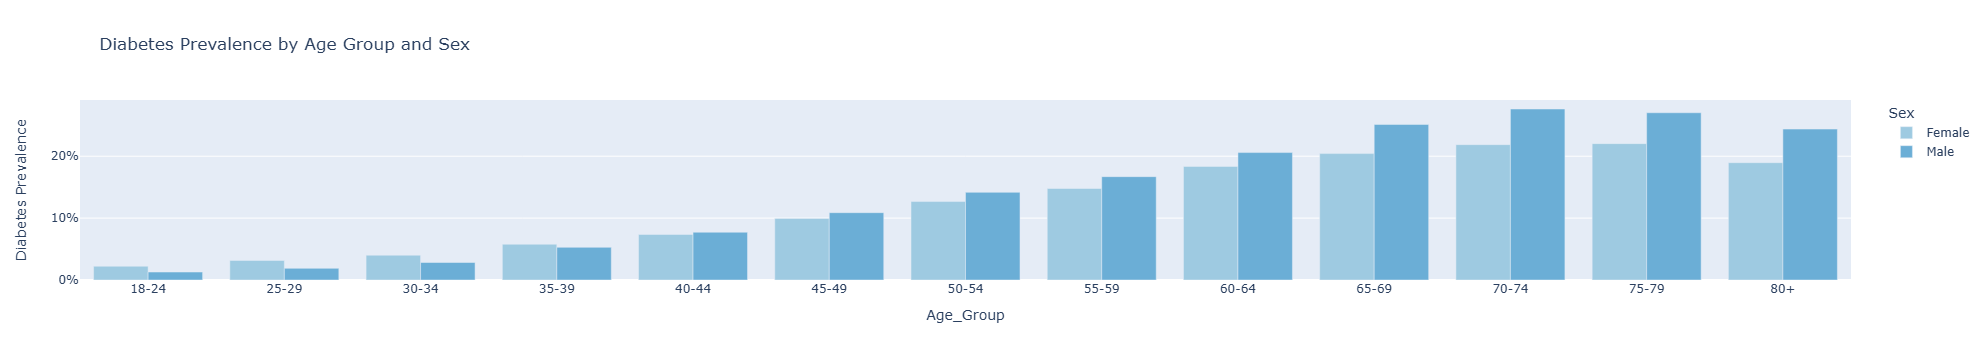

In [50]:
# Map age group numbers to ranges
age_group_mapping = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39',
    5: '40-44', 6: '45-49', 7: '50-54', 8: '55-59',
    9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
    13: '80+'
} #we are trying to map each numerica age groups to typical human age ranges

diabetes_df['Age_Group'] = diabetes_df['Age_Group'].map(age_group_mapping)  #replaces each agr group code with the one we just mapped
diabetes_df['Sex'] = diabetes_df['Sex'].map({0:'Female', 1:'Male'})  #converting the binary numerics to readable labels 

age_sex = diabetes_df.groupby(['Age_Group', 'Sex'], as_index=False)['Diabetes_Class'].mean()  #grouped the data by age group and sex and used diabetes as mean to show its prevelance in that group

fig = px.bar(
    age_sex, # new grouped table
    x='Age_Group',
    y='Diabetes_Class',
    color='Sex',
    barmode='group',
    title='Diabetes Prevalence by Age Group and Sex',
    labels={'Diabetes_Class':'Diabetes Prevalence'},
    color_discrete_sequence=px.colors.sequential.Blues[3:5] 
)
fig.update_yaxes(tickformat=".0%") #formats the y-axis as percentage instead of 0.10
fig.show()


**Observations**

X-axis: Age Groups (1 = youngest, 13 = oldest; mapped to age ranges).

Color legend: Sex (0 = Female, 1 = Male).

Y-axis: Diabetes prevalence (percentage of people with diabetes in each age-sex group).

Insights

Strong age effect: Diabetes prevalence increases steadily with age for both men and women.

Young adults (18–34): Very low prevalence (<10%), minimal difference between sexes.

Mid-age (35–54): Prevalence rises to ~15–25%, with males slightly higher than females.

Older adults (55–69): Significant increase (~25–35%), male-female gap widens.

Elderly (70+): Highest prevalence (~40–50%), males consistently higher than females.

**Overall, age is a major risk factor, and men may tend to have a higher prevalence than women in nearly every age group, especially in older populations**

On doing research I found that, as men tend to grow older, they produce lesser levels of testosterone and that direct increases their insulin resistance. Conversely, women have higher chances of diabetes because they typically go through body changes such as pregnancy which can affect their hormonal levels and cause diabetes

As people age, they loose a lot of their muscle mass to fat and this leads to insulin resistance. Thus, it is not unusal to see that trend.



<a id="baseline-model"></a>
## Baseline Model


Now that the data is pre-processed with some preliminary insights, we will proceed with baseline modelling. Baseline modelling gives us a good starting point to compare advanced models. The parameters are usually kept default and no hyper-parameter tuning is done at this stage.

Since this is a classification task, we will use a **Logistic Regression** model. We will use our encoded dataframe for the modelling.

Splitting the data into features and target

In [51]:
X = df_encoded.drop('Diabetes_Class', axis=1)
y = df_encoded['Diabetes_Class']

In [52]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,Veggies,...,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income,General_Health_2,General_Health_3,General_Health_4,General_Health_5
0,1,1,1,40,1,0,0,0,0,1,...,15,1,0,9,4,3,False,False,False,True
1,0,0,0,25,1,0,0,1,0,0,...,0,0,0,7,6,1,False,True,False,False
2,1,1,1,28,0,0,0,0,1,0,...,30,1,0,9,4,8,False,False,False,True
3,1,0,1,27,0,0,0,1,1,1,...,0,0,0,11,3,6,True,False,False,False
4,1,1,1,24,0,0,0,1,1,1,...,0,0,0,11,5,4,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,5,0,1,5,6,7,False,True,False,False
253676,1,1,1,18,0,0,0,0,0,0,...,0,1,0,11,2,4,False,False,True,False
253677,0,0,1,28,0,0,0,1,1,0,...,0,0,0,2,5,2,False,False,False,False
253678,1,0,1,23,0,0,0,0,1,1,...,0,0,1,7,5,1,False,True,False,False


In [53]:
y

0         0
1         0
2         0
3         0
4         0
         ..
253675    0
253676    1
253677    0
253678    0
253679    1
Name: Diabetes_Class, Length: 253680, dtype: int64

<a id="stratify-split"></a>
### Stratify Split


I have decided to split the data into **80% training and 20% testing**.
Since my dataset is imbalanced, I used stratification to ensure that both the training and test sets preserve the original class proportions. This prevents the model from being biased due to class imbalance in either subset.

Using a random_state ensures reproducibility, meaning the split will be the same every time the code is run.


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=101
)

<a id="feature-engineering-2"></a>
### Feature Engineering 2 - Standard Scalar


Machine learning models are senstive to feature inputs. If feature inputs are on different scales such that one scale (unit) dominates the other, the results would be biased.

To avoid that, we need to scale the features to common unit.

**Note: All scaling should be done **after** train/test split to avoid leaking information from your test set into your training data**. 

In [55]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

**StandardScaler()** : initializes the scaler. It doesn't do anything yet — it's just preparing the tool to learn the mean and standard deviation of each feature.

**scaler.fit_transform(X)**:

This does two things:

**fit(X)**: Calculates the mean and standard deviation for each feature in the dataset X.

**transform(X)**: Applies the standardization across the dataset

**X_train/test_scaled**- a new numpy array having all features standardized 

<a id="logistic-regression-normal"></a>
### Logistic Regression — Normal


In [56]:
# 1. Instantiate model
log_reg = LogisticRegression(max_iter=1000, random_state=101)

# Fit on training data
log_reg.fit(X_train_scaled, y_train)

# 3. Score on the training data
print(f"The training accuracy of the model is {log_reg.score(X_train_scaled, y_train)}")

# 4. Score on the testing data
print(f"The test accuracy of the model is {log_reg.score(X_test_scaled, y_test)}")

The training accuracy of the model is 0.847918637653737
The test accuracy of the model is 0.8491406496373384


Here, I have tried to score the model on both training and test set. Since both gave **high accuracy (84%)** , it signifies a good fit **(no over or under fitting)**. The model has successfully identified the relationship between the features and the target variable.

**model.score()** internally calls **model.predict()** to get predictions and then calculates a default metric based on the model type (e.g., accuracy for classification, R-squared for regression).

Since, our model is not overfitting, there is no need to further optimize the regularization hyperparameter for logisitic regression.

However, it is important to note that **just relying on the accuracy score especially when the data is highly imbalanced can be misleading**. This score could be over representing the class (in this case people with no diabetics) more than cases with people who have diabetes. Thus, we will explore other metrics (below) and gather insights.

<a id="classification-report-normal"></a>
#### Classification Report-Normal



Even though .score() gives accuracy, it does not work well for our imbalanced data set (our case). We will explore classification report:

**Precision**- How often the prediction is correct? In other words, of all people the model said are diabetic, how many were actually diabetic??

Precision measures what proportion of a model assigned to positive are actually members of the positive class

**Recall**- Out of all the actual cases, how many classes were identified properly? In other words, of all actual diabetic people, how many did the model correctly catch?

Recall measures how many members of the positive class the model correctly identified out of the total positives

**F1 score**- Harmony mean of the model- Balance of Precision & Recall

**Classification_report** gives us a complete picture about precision, recall, and  𝐹1 score for both the positive class and also the negative class

In [57]:
# Remember the goal of the project

From a **healthcare industry** perspective, the most important evaluation metric should be **Recall**. Our goal is to build a model which detects diabetic patients from a health survey data. The model should be able to flag people who are likely diabetic so they can get further tests or care. Although not ideal, we can sacrifice precision because even if healthy people are incorrectly diagnosed, they can take further tests and be cleared. Classification report helps us get a clear picture of precision, recall and F1 score.

In [58]:
# Evaluation on Test Set
y_pred = log_reg.predict(X_test_scaled)  #classification report

**log_reg.predict**: Helps us to get predicted class label for each test sample. We need this to generate the confusion matrix and generate the classification report

In [59]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.92     42741
           1       0.57      0.18      0.27      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.58      0.60     50736
weighted avg       0.82      0.85      0.81     50736



**Observations**




**Class 0**: Represents cases where people do not have diabetes. It can be seen that both **precision (0.85) and recall (0.97)** are very high and the model is able to accurately predict the right class and identify patients with no diabetes.

**Class 1**: Represents cases where people are diabetic. Both **precision (0.56) and recall (0.18)** are very low. **Low recall means that the model misses a lot of actual diabetics. Low precision means a lot of patients were diagnosed incorrectly as diabetic**.

Since, as it was mentioned earlier, the main evaluation metric is recall. Having such low recall for one of the classes means the model is not efficient and must be improved.

**There is no point and going to check for other evaluation metric when the main criteria of recall has failed**.

Thus, I will be directly exploring **balanced** & **upsampling** technique.

<a id="logistic-regression-balanced"></a>
### Logistic Regression — Balanced


As our data set is highly imbalanced, we can try to minimize its impact on the model by increasing the penalty for misclassifying the minority class. Class weight parameter automatically adjusts weights inversely proportional to class frequenceis. This technique helps tell the alogrithm to pay more attention to the minority classs by increasing its error costs

In [60]:
# 1. Instantiate model
log_reg = LogisticRegression(max_iter=1000, random_state=101,class_weight='balanced') #balanced introduced here

# Fit on training data
log_reg.fit(X_train_scaled, y_train)

# 3. Score on the training data
print(f"The training accuracy of the model is {log_reg.score(X_train_scaled, y_train)}")

# 4. Score on the testing data
print(f"The test accuracy of the model is {log_reg.score(X_test_scaled, y_test)}")

The training accuracy of the model is 0.7261412015137181
The test accuracy of the model is 0.7297185430463576


In [61]:
# Evaluation on Test Set
y_pred = log_reg.predict(X_test_scaled)  #confusion matrix and classification report

<a id="classification-report-balanced"></a>
#### Classification Report-Balanced


In [62]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.65     50736
weighted avg       0.85      0.73      0.76     50736



The accuracy scores went down from **83 % to 72 %**

**Class 0**: It can be seen that precision (0.94) has improved but recall (0.72) has reduced. Not the most ideal situation

**Class 1**: Precision (0.34) has reduced but recall (0.77) has significantly improved. 

This means that **class weight= balanced has improved our overall model performance** as per the goal but in the process we sacrificed some precision.

<a id="logistic-regression-upsampling"></a>
### Logistic Regression Model — Upsampling


To potentially improve our model, we can "upsample" the minority class. This entails us resampling the observations that belong to the under-represented class so that our training data consists of equal proportions of each class.

A very important note here is that it should be done only to the **training data**. The test data should remain untouched and have class imbalance consistent with what you would expect the real world to be

In [63]:
# Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=101
)

In [64]:
# Upsample (only X_train, y_train)

# we are trying to duplicate minority class (Class 1: Diabetic) samples in the training set to balance it with the majority class (Class 0: Non-Diabetic)

# Show number of diabetic (1) samples before upsampling

print("Number of class 1 (diabetic) examples before:", X_train[y_train == 1].shape[0])   #shape[0] gives the number of rows

X_pos = X_train[y_train == 1] # pulls out only the positive cases where diabetes is 1 from training set. This is the minority class we want to duplicate

y_pos = y_train[y_train == 1] # corresponding target values which will all be 1

# make copies of positive cases until they match the number of negative cases
X_dup, y_dup = resample(
    
    X_pos, 
    
    y_pos, 
    
    replace=True, # same row can be picked more than once; needed when we dont have enough unique diabetic rows
    
    n_samples=X_train[y_train == 0].shape[0], # gets the target number of samples to match the number of non-diabetic patients in training data
    
    random_state=17  #for reproducibility
)

print("Number of class 1 (diabetic) examples after:", X_dup.shape[0])    #after duplication how many diabetic samples

# Combine majority class (0) with upsampled minority class (1)

X_train_upsampled = np.vstack((X_train[y_train == 0], X_dup)) #Stacking 2 arrays including non-dibaetic and upsampled diabetic, thus making a new training set

y_train_upsampled = np.hstack((y_train[y_train == 0], y_dup)) #stacks the target values for both diabetic and non-diabetic

# convert to DataFrame

X_train_upsampled = pd.DataFrame(X_train_upsampled, columns=X_train.columns) #converts to dataframe and keeps the original column names

Number of class 1 (diabetic) examples before: 31982
Number of class 1 (diabetic) examples after: 170962


The minority class representation improved **significantly**

Now that the data is upsampled, let's scale the data.

In [65]:
#scale the dataframe after upsampling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_upsampled)
X_test_scaled = scaler.transform(X_test)  # use original test set

In [66]:
model = LogisticRegression(max_iter=1000, random_state=101)
model.fit(X_train_scaled, y_train_upsampled)

LogisticRegression(max_iter=1000, random_state=101)

<a id="classification-report-upsampling"></a>
#### Classification Report-Upsampling


In [67]:
# Predict on the scaled test set by using our trained logistic regression model
y_pred = model.predict(X_test_scaled)  

# Predict probabilities for each test sample (useful for ROC AUC)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
train_accuracy = model.score(X_train_scaled, y_train_upsampled)
test_accuracy = model.score(X_test_scaled, y_test)

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))


Training Accuracy: 74.24 %
Test Accuracy: 72.9 %

 Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736



**Observations**


The accuracy scores increased to **aprrox. 74 %**. This score is acceptable for a baseline model. 

The class precision and recall remain same as the class weighted model.

The similarity in results suggests that for this dataset and model, either method is equally effective. In deployment, class weighting may be preferred for efficiency, while upsampling remains an option for algorithms that lack class weight support.


<a id="advanced-evaluation-metrics"></a>
### Advanced Evaluation Metrics


We can use other evaluation metrics from our tool kit and gather more insights.

**Confusion Matrix** gives us a better understanding where misclassifications occur. 

**Reciever Operator Characteristic (ROC) AUC curve**: The ROC is a graphical measure which compares the true positive and false positive rates of a binary model. The AUC curve provides a measure of model's quality. The AUC is advantageous as a performance metric because it captures both the performance in the negative and positive class unlike the F1 score. It also is unique in that it does not change depending on the probability threshold, because it is calculated looking at all of the thresholds. Eventually, it helps us adjust the model in order to strike the correct balance

**Precision-Recall Curve**: This curve is more suited for imbalanced database. As the name suggest, this model gives the curve between precisio and recall. This curve puts spotlight on how well a model finds actual positives without being influced by majority class.


**Confusion Matrix**

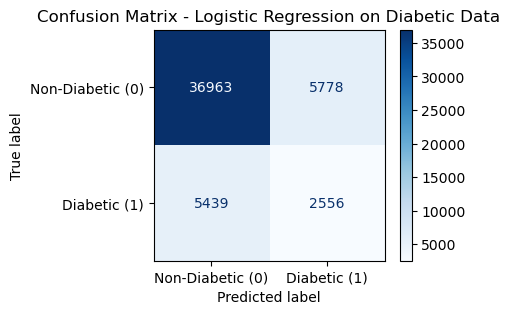

In [78]:
# y_test: true labels
# y_pred: predictions from logistic regression
cm = confusion_matrix(y_test, y_pred) 

# Display it nicely

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic (0)", "Diabetic (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression on Diabetic Data")
plt.savefig("Confusion.png", dpi=300, bbox_inches='tight')
plt.show()


**True Negatives (TN): 26,823**

- These are non-diabetic correctly predicted as non-diabetic

**False Positives (FP): 11,189**

- These were actually negative, but the model mistakenly labeled them positive.

In this context: non diabetics that were incorrectly flagged as diabetic

**False Negatives (FN): 1,928**

- These were actually positive, but the model predicted them as negative.

So diabetic cases that the model missed.

**True Positives (TP): 6017**

- Diabetic correctly predicted as Diabetic.
    
The model now has better balance between sensitivity (recall) and specificity, which is crucial in healthcare models.

**(ROC) AUC curve**

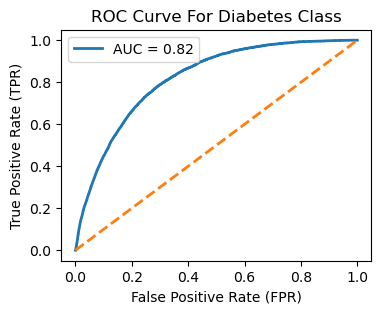

Area under curve (AUC):0.8184511844902479



In [74]:
# Building an ROC AUC Curve

fp_rate, tp_rate, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()

plt.plot(fp_rate, tp_rate, lw=2, label="AUC = %0.2f" % roc_auc)#  x is FPR and y is TPR
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve For Diabetes Class")
plt.legend(loc="best")
plt.savefig("ROC_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Area under curve (AUC):{roc_auc}")
print()

**Observations**

Here we are plotting between the False Positive Rate (FPR), True Positive Rate (TPR) at various classification thresholds. A curve closer to the top left corner indicates a better model as it achieves a high recall with low false positive rate. 

Our curve being well above the diagonal (random guessing) line means the model is significantly better than random classification

**TPR**: Ability to catch diabetics

**FPR**: wrongly labeling non-diabetics as diabetics

**y_test**: true labels

**y_proba**: predicted probabilities for class 1 (diabetic)

**roc_auc = roc_auc_score(y_test, y_proba)**: calculates the Area Under the ROC Curve (AUC), which quantifies model performance

An AUC of 0.818 means that there is an **81.8% chance that the model will correctly distinguish a randomly chosen diabetic patient from a non-diabetic patient**.

The dash line represents random guessing and our curve is well above that which is good. ROC is threshold-independent, so it gives a more complete picture of model performance than accuracy.


**However, since our data set is highly imbalanced, ROC AUC curve considers true negatives in its calculation. In our case, we have lot of true negatives (26,823) which can skew our results. So even if the ROC-AUC score looks high,  the models may still not be very good at finding the true positives**

For this reason, we rely on another metric called **PR Curve** which primarly focuses only on the positve class and ignores the true negatives

**PR Curve**

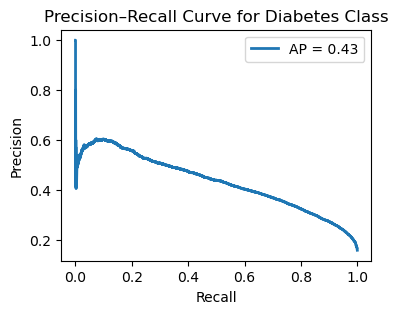

Average Precision (AP): 0.43


In [75]:
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Plot PR Curve
plt.figure()
plt.plot(recall, precision, lw=2, label='AP = %0.2f' % avg_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve for Diabetes Class')
plt.legend(loc="best")
plt.savefig("PC_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Average Precision Score
print(f"Average Precision (AP): {avg_precision:.2f}")

**Observations**

Average Precision (AP) = 0.43. This is the area under the PR Curve. It means that whenever our model predicts 'diabetic', it is correct 43 % of the time across all recall levels.

In imbalanced dataset this curve is more representative as it primarly focuses on the positive class. 

The curve starts high on the left (high precision, low recall)- meaning if we have very strict threshold, we will get fewer predictions but more accuracy.
As recall increases, precision drops, meaning to catch more diabetics, we have to accept (sacrific) more false positives.
Smooth decline shows the trade of between catching all positive cases and keeping predictions accurate.

In advanced modelling, I will explore how I can manage the balance between precision and recall to get better results.

<a id="summary-baseline-models"></a>
### Summary of Baseline Models (Class 1 — Diabetic)


| Method                       | Train Accuracy | Test Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | Key Observation |
|------------------------------|----------------|---------------|---------------------|------------------|--------------------|-----------------|
| **Baseline (No Balancing)**  | ~84%           | ~84%          | ~0.65               | ~0.18            | ~0.28              | Very high accuracy due to class imbalance; fails to identify most diabetics (low recall). |
| **Class Weight = 'balanced'**| ~72%           | ~72%          | 0.34                | 0.77             | 0.47               | Recall for diabetics improved drastically (~4× higher); accuracy dropped due to better focus on minority class. |
| **Upsampling (Minority Class)** | ~74%        | ~73%          | 0.34                | 0.77             | 0.47               | Very similar to class_weight results; recall gain same as 'balanced', but accuracy slightly higher than balanced on training & test. |


<a id="logistic-regression-upsample-interpretation"></a>
## Logistic Regression-Upsample Interpretation


In [83]:
# Extracting the coefficients
# Get feature names
feature_names = X_train.columns  

# Get coefficients
coef = model.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef,
    "Odds Ratio": np.exp(coef)   # converting log-odds to odds ratio
}).sort_values(by="Odds Ratio", ascending=False)

coef_df.head(10)  # Top 10 features

,Feature,Coefficient,Odds Ratio
22,General_Health_4,0.683390,1.980580
21,General_Health_3,0.619214,1.857468
3,BMI,0.514004,1.671972
23,General_Health_5,0.500520,1.649579
17,Age_Group,0.420691,1.523013
0,HighBP,0.345191,1.412259
1,HighChol,0.298372,1.347663
20,General_Health_2,0.298331,1.347607
2,CholCheck,0.187618,1.206373
16,Sex,0.128596,1.137231


For interpretation purposes, it is important to take out the coefficients and see how each features impact diabetes. However, the coefficeints alone are difficult to interpret, so it is essential to find the **odds ratio** to establish meaninful relations.

- **Odds Ratio > 1:** The feature increases the odds of diabetes.  
- **Odds Ratio < 1:** The feature decreases the odds of diabetes.  
- **Odds Ratio = 1:** No effect on diabetes odds.

**Note that for General Health- When one hot encoding was done, Excellent (General Health 1) was chosen as the reference group. Similarly, for sex, 0 (female) is used as reference group automatically by the model**


**Observations**

- **General Health (4 = "Fair") - OR = 1.98**  
  Individuals reporting fair health are nearly **2x more likely** to have diabetes compared to the reference group (excellent health).

- **General Health (3 = "Good") - OR = 1.85**  
  Those with good health have about **85% higher odds** of diabetes than the healthiest group.

- **BMI = 1.67**  
  Higher BMI significantly increases diabetes risk. For each unit increase in BMI (scaled), the odds of diabetes rise by **~67%**.

- **General Health (5 = "Poor") - OR = 1.64**  
  Reporting poor health is associated with a strong increase in diabetes likelihood.

- **Age Group = 1.52**  
  Older individuals have **52% higher odds** of diabetes compared to the youngest group.

- **High Blood Pressure = 1.41**  
  Those with high blood pressure are **41% more likely** to have diabetes.

- **High Cholesterol = 1.34**  
  Cholesterol problems moderately increase diabetes risk.
  
- **CholCheck = 1.2**  
  Individuals who had a cholesterol check show ~20% higher odds of diabetes — possibly because people at risk are more likely to get tested. 
  
- **Sex = 1.13**  
  Male have **13% higher** odds of diabetes compared to female 
  

**Possible Explainations**

Although we might expect 'Poor' health to have the highest risk, in this dataset 'Fair' shows the strongest association. The model is actually following the order: **Fair (highest risk of diabetes) > Good > Poor > 
Excellent**. Possible Explainations for this could be:

- People might not rate themselves consistently. Meaning, even if someone has diabetes, they might still call their health 'fair' rather than 'poor'
- Sample size imbalance have skewed those observations. Looking at the dataset, only fraction of people have called themselves 'poor'. This means the model has lost its statistical power.
- Also, it is important to remember the model is not saying that poor health is less likely to cause diabetes, it is just say saying that the model shows other cateogries having stronger assoication to diabetes.

Males have **~13% higher odds of diabetes compared to females**. Possible explainations for this could be:

- Men tend to have more visceral fat (around the abdomen), which is strongly linked to insulin resistance and diabetes.
- As men age, the testosterone levels decrease and that is attributed to higher insulin resitance.

BMI increases relates to higher diabetes because it leads to obesity and medical studies have shown obesity to be the gateway for this disease.

People with age have higher chances of diabetes because as the body becomes older, their muscle mass reduces and fat mass increases. This can lead to insulin resistance

High BP reduces the ability for blood to circulate around the body. This direct impacts the insulin delivery for cells to use and leads to higher blood sugar levels

High Cholestrol is known to be medically linked with diabetes and thus this trend makes sense

CholCheck is a measure to find if someone is having diabetes or not. So people who typical get themselves checked, will have higher chances of finding out if they have the disease






